In [1]:
# ============================================================
# Clears workspace, clones LabelBench, installs dependencies
# ============================================================

!rm -rf /kaggle/working/*
!git clone https://github.com/EfficientTraining/LabelBench.git
!pip install -r /kaggle/working/LabelBench/requirements.txt
%cd /kaggle/working/LabelBench

Cloning into 'LabelBench'...
remote: Enumerating objects: 2858, done.
remote: Counting objects: 100% (479/479), done.
remote: Compressing objects: 100% (278/278), done.
remote: Total 2858 (delta 248), reused 326 (delta 185), pack-reused 2379 (from 1)
Receiving objects: 100% (2858/2858), 111.50 MiB | 32.77 MiB/s, done.
Resolving deltas: 100% (1483/1483), done.
Updating files: 100% (1415/1415), done.
  Cloning https://github.com/openai/CLIP.git to /tmp/pip-req-build-a3cfz5pc
  Running command git clone --filter=blob:none --quiet https://github.com/openai/CLIP.git /tmp/pip-req-build-a3cfz5pc
  Resolved https://github.com/openai/CLIP.git to commit ded190a052fdf4585bd685cee5bc96e0310d2c93
  Preparing metadata (setup.py) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 44.8/44.8 kB 3.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 126.2/126.2 kB 6.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.5/1.5 MB 28.0 MB/s eta 0:00:00a 0:00:01
   ━━━━━━━━━━━━━━━━━━━

In [2]:
ls

configs/        LabelBench/  mp_eval_launcher.py  README.md
docs/           LICENSE      mp_launcher.py       requirements.txt
example_run.sh  main.py      point_evaluation.py  results/


## closed world dataloader

In [3]:
import torch
import torch.nn.functional as F
from torchvision import datasets as tv_datasets, transforms
from torch.utils.data import Dataset
from LabelBench.skeleton.dataset_skeleton import register_dataset, LabelType, TransformDataset
import numpy as np

import random
SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
torch.cuda.manual_seed_all(SEED)
torch.backends.cudnn.deterministic = True
torch.backends.cudnn.benchmark = False
# torch.use_deterministic_algorithms(True)

NUM_TASKS = 9   # Total number of incremental tasks
# NUM_TASKS = 40   # Total number of incremental tasks


# ------------------------------------------------------------
# Dataset wrapper to expose only a subset of CIFAR-10 indices
# ------------------------------------------------------------
class CIFARStream(Dataset):
    def __init__(self, base_ds, indices):
        self.base_ds = base_ds      # Full CIFAR-10 dataset
        self.indices = indices      # Indices assigned to this task

    def __len__(self):
        return len(self.indices)

    def __getitem__(self, idx):
        # Fetch the actual sample using stored indices
        x, y = self.base_ds[self.indices[idx]]
        return x, y


# ------------------------------------------------------------
# One-hot encoding helper (required by LabelBench)
# ------------------------------------------------------------
def one_hot(y, n=10):
    return F.one_hot(torch.tensor(y), num_classes=n).float()


# ------------------------------------------------------------
# Base dataset registry (intentionally disabled)
# ------------------------------------------------------------
@register_dataset("splitcifar10", LabelType.MULTI_CLASS)
def get_splitcifar10(_):
    # Prevent accidental usage of the base dataset
    raise RuntimeError("Use splitcifar10_<id>")


# ------------------------------------------------------------
# Build task stream ONCE (randomized split of CIFAR-10)
# ------------------------------------------------------------
base_train_global = tv_datasets.CIFAR10(root="./data", train=True, download=True)
all_idx = np.arange(len(base_train_global))
# np.random.shuffle(all_idx)
rng = np.random.default_rng(SEED)
rng.shuffle(all_idx)
stream_splits = np.array_split(all_idx, NUM_TASKS)


# ------------------------------------------------------------
# Register each task dynamically
# ------------------------------------------------------------
for split_id in range(NUM_TASKS):

    @register_dataset(f"splitcifar10_{split_id}", LabelType.MULTI_CLASS)
    def _make_split(data_dir, split_id=split_id):

        tf = transforms.Compose([transforms.ToTensor()])

        base_train = tv_datasets.CIFAR10(root=data_dir, train=True, download=True)
        base_test  = tv_datasets.CIFAR10(root=data_dir, train=False, download=True)

        
        # ----------------------------------------------------
        # TASK 0: Base session (only classes 0 and 1)
        # Fully supervised
        # ----------------------------------------------------
        if split_id == 0:
            indices = [i for i,(x,y) in enumerate(base_train) if y in [0,1]]
        elif 1 <= split_id <= 8:
            new_class = split_id + 1
            indices = [i for i,(x,y) in enumerate(base_train) if y == new_class]
        else:
            indices = []

        train_ds = CIFARStream(base_train, indices)

        # Wrap dataset with transforms + one-hot labels
        train_ds = TransformDataset(
            train_ds,
            transform=tf,
            target_transform=lambda y: one_hot(y,10)
        )

        test_ds = TransformDataset(
            base_test,
            transform=tf,
            target_transform=lambda y: one_hot(y,10)
        )

        return train_ds, test_ds, test_ds, None, None, None, 10, [str(i) for i in range(10)]

100%|██████████| 170M/170M [00:03<00:00, 48.0MB/s] 


## Closed world model pipeline 
#### herd sampling and not random sampling, more robust way

Downloading: "https://download.pytorch.org/models/resnet18-f37072fd.pth" to /root/.cache/torch/hub/checkpoints/resnet18-f37072fd.pth


100%|██████████| 44.7M/44.7M [00:00<00:00, 215MB/s]



================ TASK 0 ================
[TSNE-SUPERVISED] Task 0 Epoch 0
[TSNE-SUPERVISED] Task 0 Epoch 5
[TSNE-SUPERVISED] Task 0 Epoch 10
[TSNE-SUPERVISED] Task 0 Epoch 15
[TSNE-SUPERVISED] Task 0 Epoch 20
[TSNE-SUPERVISED] Task 0 Epoch 25
[METRIC] Known-Class Acc = 0.981

================ TASK 1 ================
[NEW CLASS DETECTED] Semantic label: 2
[TSNE-FINETUNE] Task 1 Epoch before
[TSNE-FINETUNE] Task 1 Epoch 0
[TSNE-FINETUNE] Task 1 Epoch 5
[TSNE-FINETUNE] Task 1 Epoch 10
[METRIC] Known-Class Acc = 0.890

================ TASK 2 ================
[NEW CLASS DETECTED] Semantic label: 3
[TSNE-FINETUNE] Task 2 Epoch before
[TSNE-FINETUNE] Task 2 Epoch 0
[TSNE-FINETUNE] Task 2 Epoch 5
[TSNE-FINETUNE] Task 2 Epoch 10
[METRIC] Known-Class Acc = 0.832

================ TASK 3 ================
[NEW CLASS DETECTED] Semantic label: 4
[TSNE-FINETUNE] Task 3 Epoch before
[TSNE-FINETUNE] Task 3 Epoch 0
[TSNE-FINETUNE] Task 3 Epoch 5
[TSNE-FINETUNE] Task 3 Epoch 10
[METRIC] Known-Class Acc

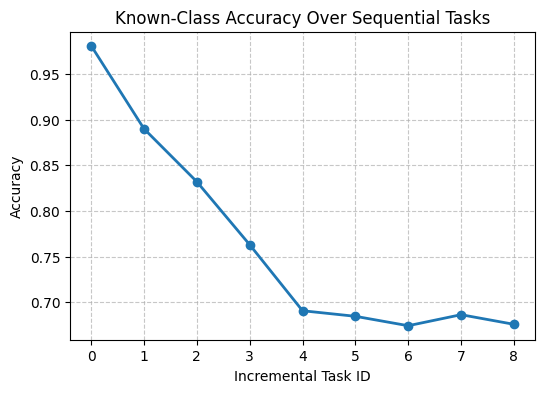

In [4]:
import os
import torch
import torch.nn as nn
import torch.nn.functional as F
import numpy as np
import matplotlib.pyplot as plt
from collections import defaultdict
from torch.utils.data import DataLoader, TensorDataset
from sklearn.manifold import TSNE
import torchvision.transforms as T
from torchvision.models import resnet18
from LabelBench.skeleton.dataset_skeleton import datasets as DATASET_REGISTRY
import copy

BASE_DIR = "debug_raw_memory"

os.makedirs(BASE_DIR, exist_ok=True)
os.makedirs(f"{BASE_DIR}/tsne", exist_ok=True)
os.makedirs(f"{BASE_DIR}/tsne_supervised", exist_ok=True)
os.makedirs(f"{BASE_DIR}/tsne_finetune", exist_ok=True)
os.makedirs(f"{BASE_DIR}/drift", exist_ok=True)

# ============================================================
# CONFIGURATION
# ============================================================

NUM_TASKS = 9
DEVICE = "cuda" if torch.cuda.is_available() else "cpu"

CIFAR10_LABELS = {
    0: "airplane", 1: "automobile", 2: "bird", 3: "cat",
    4: "deer", 5: "dog", 6: "frog", 7: "horse",
    8: "ship", 9: "truck"
}

# ============================================================
# MODEL DEFINITION (ADAPTER RESTORED)
# ============================================================

class CNN(nn.Module):
    def __init__(self, num_classes):
        super().__init__()
        base = resnet18(weights='DEFAULT')
        self.encoder = nn.Sequential(*list(base.children())[:-1])
        
        # RESTORED: This is critical for adapting ImageNet to 32x32 CIFAR
        self.embed = nn.Linear(512, 512)
        self.classifier = nn.Linear(512, num_classes, bias=False)
        self.scale = 20.0  #cosine classifier scaling

    def expand_head(self, new_classes):
        old_w = self.classifier.weight.data.clone()
        old_n = old_w.shape[0]
        new_classifier = nn.Linear(512, new_classes, bias=False).to(old_w.device)
        new_classifier.weight.data[:old_n] = old_w
        self.classifier = new_classifier

    def forward(self, x, labels=None):
        # ALLOW ENCODER TO ADAPT AGAIN
        z = self.encoder(x)       #64,3,32,32 to 64,512,1,1
        z = z.view(z.size(0), -1) #reshape the tensor obtained in self.encoder(x) to 64, 512
        z = self.embed(z)         #64,512 feature adaptation for CIFAR10
            
        z = F.normalize(z, dim=1)  #normalize embedding vectors
        W = F.normalize(self.classifier.weight, dim=1) #normalize weight vectors
        cosine = torch.matmul(z, W.t()) #similarity to class0, class1
    
        if labels is not None: #ArcFace (angular margin) is applied
            m = 0.2 
            theta = torch.acos(torch.clamp(cosine, -1+1e-7, 1-1e-7))
            target_logits = torch.cos(theta + m)
            one_hot = F.one_hot(labels, num_classes=W.size(0)).float()
            logits = cosine * (1 - one_hot) + target_logits * one_hot
        else:
            logits = cosine
    
        logits = logits * self.scale
        return logits, z


# ============================================================
# CENTROID DRIFT TRACKER
# ============================================================

class DebugCentroidTracker:
    def __init__(self):
        self.reference = {}
        self.history = defaultdict(list)

    def compute_centroids(self, model, memory):
        model.eval()
        centroids = {}
        with torch.no_grad():
            for cls, Xs in memory.items():
                if len(Xs) == 0: continue
                X = torch.stack([x for x, _ in Xs]).to(DEVICE)
                _, Z = model(X)
                mu = F.normalize(Z.mean(0), dim=0)
                centroids[cls] = mu.detach().cpu()
        return centroids

    def snapshot(self, model, memory):
        self.reference = self.compute_centroids(model, memory)

    def measure_drift(self, model, memory, epoch, tag=""):
        current = self.compute_centroids(model, memory)
        for cls in self.reference:
            if cls in current:
                drift = 1 - torch.dot(self.reference[cls], current[cls])
                self.history[(tag, cls)].append(drift.item())
                with open(f"{BASE_DIR}/drift/{tag}.txt", "a") as f:
                    f.write(f"Epoch {epoch} Class {cls}: {drift:.4f}\n")

    def plot_drift(self, tag):
        for (t, cls), values in self.history.items():
            if t == tag: plt.plot(values, label=f"class {cls}")
        plt.legend(); plt.title(f"Centroid Drift {tag}"); plt.xlabel("Checkpoint"); plt.ylabel("1 - cosine similarity"); plt.grid(True)
        plt.savefig(f"{BASE_DIR}/drift/{tag}_plot.png"); plt.close()

# ============================================================
# MEMORY BUFFER (HERDING + BALANCED)
# ============================================================

class MemoryBuffer:
    def __init__(self, max_per_class=200):
        self.data = defaultdict(list)
        self.max_per_class = max_per_class
        self.aug = T.Compose([
            T.RandomCrop(32, padding=4), #cropping images
            T.RandomHorizontalFlip() #facing left to right
        ]) #to avoid overfitting on old classes while replaying

    @torch.no_grad()
    def build_memory_herding(self, X_all, y_label, model):
        model.eval()
        logits_all, Z_all = [], []
        
        for i in range(0, len(X_all), 128):
            batch = X_all[i:i+128].to(DEVICE)
            logits, z = model(batch)
            logits_all.append(logits.cpu())
            Z_all.append(z.cpu())
            
        logits_all = torch.cat(logits_all)
        Z_all = torch.cat(Z_all)

        class_mean = F.normalize(Z_all.mean(0), dim=0) #normalized mean of class0 and then later class1
        selected_idx = []
        features = Z_all.clone()

        for k in range(min(self.max_per_class, len(X_all))):
            if k > 0:
                S = Z_all[selected_idx].sum(0)
            else:
                S = torch.zeros_like(class_mean)
            
            target = (k + 1) * class_mean - S
            distances = torch.norm(features - target, dim=1)
            
            for idx in selected_idx:
                distances[idx] = float('inf')
            
            best = distances.argmin().item()
            selected_idx.append(best)

        for idx in selected_idx:
            self.data[int(y_label)].append((X_all[idx].detach().cpu(), logits_all[idx].detach().cpu()))
    
    def get(self): return self.data

    def sample_balanced(self, batch_size, model):
        classes = list(self.data.keys())
        if not classes: return None, None, None
        
        samples_per_class = max(1, batch_size // len(classes))
        X_mem, Y_mem, L_mem = [], [], []
        current_dim = model.classifier.out_features
        
        for cls in classes:
            samples = self.data[cls]
            if len(samples) == 0: continue
            
            replace = len(samples) < samples_per_class
            idx = np.random.choice(len(samples), samples_per_class, replace=replace)
            
            for i in idx:
                x, logit = samples[i]
                if logit.shape[0] < current_dim:
                    padded = torch.zeros(current_dim); padded[:logit.shape[0]] = logit; logit = padded
                X_mem.append(x); Y_mem.append(cls); L_mem.append(logit)
                
        if not X_mem: return None, None, None
        
        X_tensor = torch.stack(X_mem)
        X_tensor = self.aug(X_tensor) 
        return X_tensor, torch.tensor(Y_mem), torch.stack(L_mem)

# ============================================================
# HYPERSPHERE NOVELTY DETECTOR
# ============================================================

class HypersphereNovelty:
    def __init__(self, q=0.90):
        self.q = q
        self.mu, self.r = {}, {}

    def update(self, memory, model):
        self.mu, self.r = {}, {}
        for k, X in memory.items():
            if len(X) == 0: continue
            X = torch.stack([x for x, _ in X]).to(DEVICE)
            with torch.no_grad(): _, Z = model(X)
            mu = F.normalize(Z.mean(0), dim=0)
            d = 1 - torch.matmul(Z, mu)
            self.mu[k] = mu
            self.r[k] = torch.quantile(d, self.q)

    def score(self, z):
        if not self.mu: return torch.tensor(0.0)
        return min([(1 - torch.dot(z, self.mu[k].to(z.device))) - self.r[k].to(z.device) for k in self.mu])


# ============================================================
# TRAINING HELPERS
# ============================================================

def train_supervised(model, loader, test_loader, task_id):
    # Train the full network to establish a strong baseline
    opt = torch.optim.Adam(model.parameters(), lr=1e-4, weight_decay=1e-4)
    
    model.train()
    for epoch in range(30):
        if epoch % 5 == 0:
            visualize_epoch_tsne(model, test_loader, task_id, epoch, known_semantics=set(semantic_to_internal.keys()), phase="supervised")
        for x, y in loader:
            x, y = x.to(DEVICE), y.argmax(1).to(DEVICE)
            loss = F.cross_entropy(model(x, y)[0], y)
            opt.zero_grad(); loss.backward(); opt.step()


# ============================================================
# FINETUNING (WITH REPLAY, DER++ & DISTILLATION)
# ============================================================

def finetune(model, memory, X_new, new_label, detector, task_id, test_loader): 
    old_model = copy.deepcopy(model).eval()
    for p in old_model.parameters(): p.requires_grad = False #old model never updated because of feature distillation later

    debug_tracker = DebugCentroidTracker()
    debug_tracker.snapshot(model, memory.data)
    
    model.train()
    aug = T.Compose([T.RandomCrop(32, padding=4), T.RandomHorizontalFlip()])
    
    Y_new = torch.full((len(X_new),), new_label, dtype=torch.long)
    loader = DataLoader(TensorDataset(X_new, Y_new), batch_size=32, shuffle=True)

    # RESTORED: Train all parameters, but gently to prevent massive drift
    for p in model.parameters(): p.requires_grad = True
    opt = torch.optim.Adam(model.parameters(), lr=1e-5, weight_decay=1e-4)

    visualize_epoch_tsne(model, test_loader, task_id, epoch="before", known_semantics=set(semantic_to_internal.keys()), phase="finetune")

    # Bumped back to 15 epochs so the un-frozen encoder can actually learn
    for epoch in range(15):
        for xb, yb in loader:
            xb = aug(xb) 
            
            X_mem, Y_mem, L_mem = memory.sample_balanced(32, model)

            #creating replay mixed with new data
            if X_mem is not None:
                xb = torch.cat([xb, X_mem], dim=0)
                yb = torch.cat([yb, Y_mem], dim=0)

            xb, yb = xb.to(DEVICE), yb.to(DEVICE)
            logits, Z = model(xb, yb)
            
            # RESTORED: Logit matching (DER++)
            if X_mem is not None:
                logits_mem = logits[-len(X_mem):]
                loss_der = F.mse_loss(logits_mem, L_mem.to(DEVICE))
            else:
                loss_der = torch.tensor(0.0, device=DEVICE)
                
            loss_ce = F.cross_entropy(logits, yb)

            # RESTORED: Feature Distillation
            with torch.no_grad(): 
                logits_old, Z_old = old_model(xb)

            mask_old = yb < new_label
            if mask_old.sum() > 0:
                loss_feat = (1 - F.cosine_similarity(Z[mask_old], Z_old[mask_old])).mean()
            else:
                loss_feat = torch.tensor(0.0, device=DEVICE)

            # The proven balance ratio
            loss = loss_ce + 0.5 * loss_der + 1.0 * loss_feat
            
            opt.zero_grad()
            loss.backward()
            opt.step()

        if epoch % 5 == 0:
            visualize_epoch_tsne(model, test_loader, task_id, epoch, known_semantics=set(semantic_to_internal.keys()), phase="finetune")
            debug_tracker.measure_drift(model, memory.data, epoch, tag=f"FT_Task{task_id}")

    model.eval()
    return debug_tracker


# ============================================================
# TSNE VISUALIZATIONS
# ============================================================

def visualize_tsne(model, loader, task_id, known_semantics, tag=""):
    model.eval()
    Z_all, Y_all = [], []
    with torch.no_grad():
        for x, y in loader:
            _, z = model(x.to(DEVICE))
            y = y.argmax(1)
            mask = torch.tensor([int(label.item()) in known_semantics for label in y])
            if mask.sum() > 0: Z_all.append(z[mask].cpu()); Y_all.append(y[mask].cpu())
    if not Z_all: return
    Z_all, Y_all = torch.cat(Z_all).numpy(), torch.cat(Y_all).numpy()
    if len(Z_all) > 3000: idx = np.random.choice(len(Z_all), 3000, replace=False); Z_all, Y_all = Z_all[idx], Y_all[idx]
    Z_2d = TSNE(n_components=2, perplexity=30, metric="cosine", random_state=42, init="pca").fit_transform(Z_all)
    plt.figure(figsize=(7,6))
    for label in sorted(np.unique(Y_all)):
        plt.scatter(Z_2d[Y_all == label, 0], Z_2d[Y_all == label, 1], s=12, alpha=0.6, label=CIFAR10_LABELS[int(label)])
    plt.title(f"Task {task_id} ({tag})"); plt.legend(fontsize=8); plt.grid(True); plt.tight_layout()
    plt.savefig(f"{BASE_DIR}/tsne/task_{task_id}_{tag}.png"); plt.close()

def visualize_epoch_tsne(model, test_loader, task_id, epoch, known_semantics, phase="supervised"):
    model.eval()
    Z_all, Y_all = [], []
    with torch.no_grad():
        for x, y in test_loader:
            _, z = model(x.to(DEVICE))
            y = y.argmax(1)
            mask = torch.tensor([int(label.item()) in known_semantics for label in y])
            if mask.sum() > 0: Z_all.append(z[mask].cpu()); Y_all.append(y[mask].cpu())
    if not Z_all: return
    Z_all, Y_all = torch.cat(Z_all).numpy(), torch.cat(Y_all).numpy()
    if len(Z_all) > 3000: idx = np.random.choice(len(Z_all), 3000, replace=False); Z_all, Y_all = Z_all[idx], Y_all[idx]
    Z_2d = TSNE(n_components=2, perplexity=30, metric="cosine", random_state=42, init="pca").fit_transform(Z_all)
    plt.figure(figsize=(7,6))
    for label in sorted(np.unique(Y_all)):
        plt.scatter(Z_2d[Y_all == label, 0], Z_2d[Y_all == label, 1], s=12, alpha=0.6, label=CIFAR10_LABELS[int(label)])
    plt.title(f"{phase} | Task {task_id} | Epoch {epoch}"); plt.legend(fontsize=8); plt.grid(True); plt.tight_layout()
    save_path = f"{BASE_DIR}/tsne_{phase}/task{task_id}_epoch{epoch}.png"
    plt.savefig(save_path); plt.close(); print(f"[TSNE-{phase.upper()}] Task {task_id} Epoch {epoch}")


# ============================================================
# MAIN CONTINUAL LEARNING LOOP
# ============================================================

TASKS = [f"splitcifar10_{i}" for i in range(NUM_TASKS)]
model = CNN(num_classes=2).to(DEVICE)
memory, detector = MemoryBuffer(max_per_class=200), HypersphereNovelty()
semantic_to_internal, internal_to_semantic, known_classes = {0: 0, 1: 1}, {0: 0, 1: 1}, 2
task_kca, learned_classes_over_time = [], []

for t, task in enumerate(TASKS):
    print(f"\n================ TASK {t} ================")
    _, dataset_fn = DATASET_REGISTRY[task]
    train_ds, test_ds, *_ = dataset_fn("./data")
    loader = DataLoader(train_ds, batch_size=64, shuffle=True)

    if t == 0:
        train_supervised(model, loader, DataLoader(test_ds, batch_size=128), t) #explain arcmargin concept
        
        for cls in [0, 1]:
            Xc = torch.cat([x[y.argmax(1) == cls] for x, y in loader]) #explain this line
            memory.build_memory_herding(Xc, cls, model) #explain herding concept
            
        detector.update(memory.get(), model)
        learned_classes_over_time.append({CIFAR10_LABELS[0], CIFAR10_LABELS[1]})
    else:
        all_semantics = []
        for _, y in loader: all_semantics.extend(y.argmax(1).tolist())
        unique_semantics = list(set(all_semantics))
        
        for sem_label in unique_semantics:
            if sem_label not in semantic_to_internal:
                print(f"[NEW CLASS DETECTED] Semantic label: {sem_label}")
                new_label = known_classes
                semantic_to_internal[sem_label], internal_to_semantic[new_label], known_classes = new_label, sem_label, known_classes + 1
                model.expand_head(known_classes); model.to(DEVICE)
                
                Xc = torch.cat([x[y.argmax(1) == sem_label] for x, y in loader])
                debug_tracker = finetune(model, memory, Xc, new_label, detector, t, DataLoader(test_ds, batch_size=128))
                
                debug_tracker.plot_drift(f"FT_Task{t}")
                
                memory.build_memory_herding(Xc, new_label, model)
                detector.update(memory.get(), model)

    current = {CIFAR10_LABELS[sem] for sem in semantic_to_internal}
    learned_classes_over_time.append(current)
    
    # ============================================================
    # EVALUATION
    # ============================================================
    correct = 0
    total_eval = 0
    model.eval()
    with torch.no_grad():
        for x_test, y_test in DataLoader(test_ds, batch_size=128):
            x_test = x_test.to(DEVICE)
            y_test = y_test.argmax(1)
            logits, _ = model(x_test)
            preds = logits.argmax(1).cpu()
            for i in range(len(y_test)):
                sem_label = int(y_test[i].item())
                if sem_label not in semantic_to_internal:
                    continue
                total_eval += 1
                internal_label = semantic_to_internal[sem_label]
                if preds[i].item() == internal_label:
                    correct += 1
    acc = correct / max(total_eval, 1)
    task_kca.append(acc)
    print(f"[METRIC] Known-Class Acc = {acc:.3f}")

    visualize_tsne(model, DataLoader(test_ds, batch_size=128), t, set(semantic_to_internal.keys()))

plt.figure(figsize=(6,4))
plt.plot(task_kca, marker='o', linewidth=2, color='#1f77b4')
plt.title("Known-Class Accuracy Over Sequential Tasks")
plt.xlabel("Incremental Task ID")
plt.ylabel("Accuracy")
plt.grid(True, linestyle='--', alpha=0.7)
plt.show()

## PARTIAL OPEN WORLD SETUP

### DATALOADER POW

In [5]:
import torch
import torch.nn.functional as F
from torchvision import datasets as tv_datasets, transforms
from torch.utils.data import Dataset
from LabelBench.skeleton.dataset_skeleton import register_dataset, LabelType, TransformDataset
import numpy as np
import random

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
torch.cuda.manual_seed_all(SEED)
torch.backends.cudnn.deterministic = True
torch.backends.cudnn.benchmark = False

# Task 0 (Base) + 40 Streaming Tasks (8 classes * 5 chunks of 1000 images)
NUM_TASKS = 41   

class CIFARStream(Dataset):
    def __init__(self, base_ds, indices):
        self.base_ds = base_ds      
        self.indices = indices      

    def __len__(self):
        return len(self.indices)

    def __getitem__(self, idx):
        x, y = self.base_ds[self.indices[idx]]
        return x, y

def one_hot(y, n=10):
    return F.one_hot(torch.tensor(y), num_classes=n).float()

@register_dataset("splitcifar10", LabelType.MULTI_CLASS)
def get_splitcifar10(_):
    raise RuntimeError("Use splitcifar10_<id>")

# Build base dataset once
base_train_global = tv_datasets.CIFAR10(root="./data", train=True, download=True)
base_train_targets = np.array(base_train_global.targets)

# ------------------------------------------------------------
# Register each task dynamically (CHUNKED CLASS-INCREMENTAL)
# ------------------------------------------------------------
for split_id in range(NUM_TASKS):

    @register_dataset(f"splitcifar10_{split_id}", LabelType.MULTI_CLASS)
    def _make_split(data_dir, split_id=split_id):

        tf = transforms.Compose([transforms.ToTensor()])
        base_train = tv_datasets.CIFAR10(root=data_dir, train=True, download=True)
        base_test  = tv_datasets.CIFAR10(root=data_dir, train=False, download=True)
        
        if split_id == 0:
            indices = [i for i, y in enumerate(base_train_targets) if y in [0, 1]]
        else:
            # Math to determine which class and which 1000-image chunk
            target_class = ((split_id - 1) // 5) + 2
            chunk_idx = (split_id - 1) % 5
            
            # Get all 5000 indices for this specific class
            class_indices = np.where(base_train_targets == target_class)[0]
            
            # Slice exactly 1000 images for this specific task
            start_idx = chunk_idx * 1000
            end_idx = start_idx + 1000
            indices = class_indices[start_idx:end_idx].tolist()

        train_ds = CIFARStream(base_train, indices)

        train_ds = TransformDataset(
            train_ds,
            transform=tf,
            target_transform=lambda y: one_hot(y,10)
        )

        test_ds = TransformDataset(
            base_test,
            transform=tf,
            target_transform=lambda y: one_hot(y,10)
        )

        return train_ds, test_ds, test_ds, None, None, None, 10, [str(i) for i in range(10)]

## Changes in the cnn model and finetune method with new accuracy and forgetting metrics 

/usr/local/lib/python3.12/dist-packages/hdbscan/robust_single_linkage_.py:175: SyntaxWarning: invalid escape sequence '\{'
  $max \{ core_k(a), core_k(b), 1/\alpha d(a,b) \}$.



[TSNE] Before Training

==================== 🚀 TASK 0 ====================
📦 [STREAM] Task 0 stream contains class(es): ['airplane', 'automobile'] (Label IDs: [0, 1])
📊 [STREAM] Total images in this chunk: 10000
🎓 [INIT] Running supervised baseline on Task 0...
✅ [INIT COMPLETE] Known classes: {'airplane', 'automobile'}
📈 [METRIC] Known-Class Acc: 0.988 | Avg Forgetting: 0.000
   ➔ Class 'airplane' Acc: 0.989
   ➔ Class 'automobile' Acc: 0.987

==================== 🚀 TASK 1 ====================
📦 [STREAM] Task 1 stream contains class(es): ['bird'] (Label IDs: [2])
📊 [STREAM] Total images in this chunk: 1000
🔍 [NOVELTY] Flagged Novel: 703/1000 | False Novelty (Knowns flagged): 0

🧠 [CLUSTERING] Running HDBSCAN on novelty buffer (Size: 400)...
  🗑️  [CLUSTER -1] NOISE: Found 400 noise samples.
📈 [METRIC] Known-Class Acc: 0.988 | Avg Forgetting: 0.000
   ➔ Class 'airplane' Acc: 0.989
   ➔ Class 'automobile' Acc: 0.987

==================== 🚀 TASK 2 ====================
📦 [STREAM] Task 2 

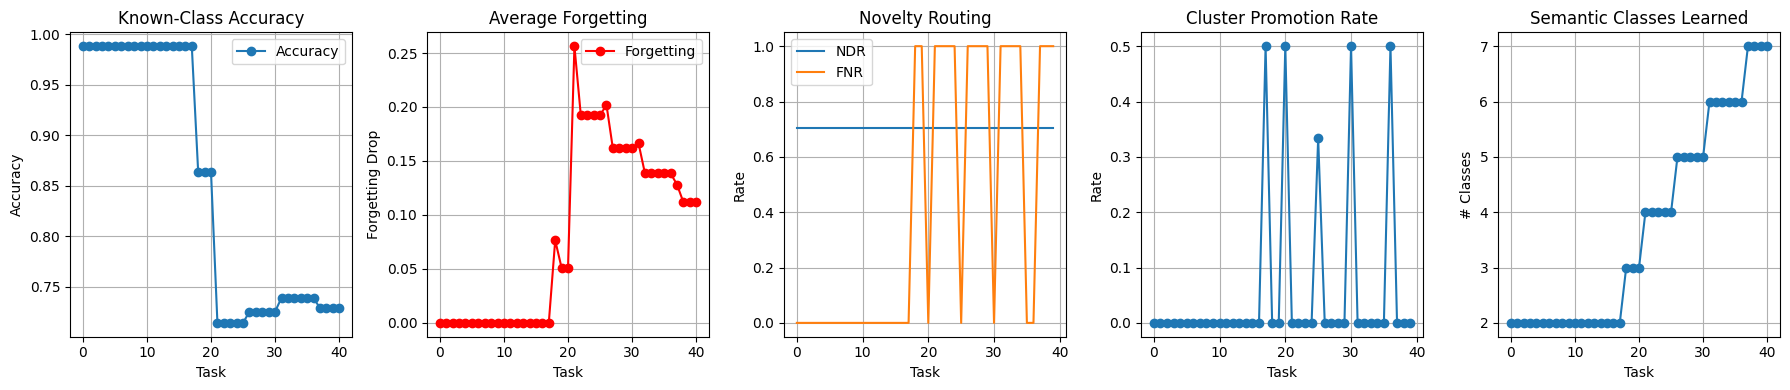

In [6]:
import os
import random
import torch
import torch.nn as nn
import torch.nn.functional as F
import numpy as np
import matplotlib.pyplot as plt
from collections import defaultdict, Counter
from torch.utils.data import DataLoader, TensorDataset
from sklearn.manifold import TSNE
import torchvision.transforms as T
from torchvision.models import resnet18
import hdbscan
import copy

# LabelBench Imports
from LabelBench.skeleton.dataset_skeleton import datasets as DATASET_REGISTRY

# ============================================================
# REPRODUCIBILITY LOCK (CRITICAL FOR CLUSTERING)
# ============================================================
def set_seed(seed=42):
    """Forces deterministic behavior for absolute reproducibility."""
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed(seed)
        torch.cuda.manual_seed_all(seed)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False
    os.environ['PYTHONHASHSEED'] = str(seed)

set_seed(42)

# ============================================================
# DIRECTORIES & CONFIGURATION
# ============================================================
BASE_DIR = "debug_raw_memory"

os.makedirs(BASE_DIR, exist_ok=True)
os.makedirs(f"{BASE_DIR}/tsne", exist_ok=True)
os.makedirs(f"{BASE_DIR}/tsne_supervised", exist_ok=True)
os.makedirs(f"{BASE_DIR}/tsne_finetune", exist_ok=True)
os.makedirs(f"{BASE_DIR}/hdbscan", exist_ok=True)
os.makedirs(f"{BASE_DIR}/drift", exist_ok=True)

# Assumes NUM_TASKS is defined in your dataloader cell (e.g., 41)
NUM_TASKS = 41
DEVICE = "cuda" if torch.cuda.is_available() else "cpu"

# Open-World Discovery Parameters
P = 1                          # Evaluate clusters at every single task
TOPK_NOVELTY = 400             # Grab WAY more candidates per chunk
MAX_NOVELTY_BUFFER = 2000      # Massive holding pen for 5 tasks

# ============================================================
# RELAXED CLUSTER VALIDATION THRESHOLDS
# ============================================================
ALPHA = 0.35              # Allow much looser clusters for unlearned features
BETA = 0.01               # Allow them to sit slightly closer to known classes
DELTA = 15                # Lower the density requirement 
MIN_CLUSTER_SIZE = 150    # Allow smaller pure clusters to be promoted

CIFAR10_LABELS = {
    0: "airplane", 1: "automobile", 2: "bird", 3: "cat",
    4: "deer", 5: "dog", 6: "frog", 7: "horse",
    8: "ship", 9: "truck"
}

# ============================================================
# MODEL DEFINITION (COSINE CLASSIFIER + ARCFACE)
# ============================================================
class CNN(nn.Module):
    def __init__(self, num_classes):
        super().__init__()
        base = resnet18(weights='DEFAULT')
        
        # --- FIX 1: ADAPT RESNET FOR 32x32 IMAGES ---
        # Replace the aggressive 7x7 conv and remove maxpool
        base.conv1 = nn.Conv2d(3, 64, kernel_size=3, stride=1, padding=1, bias=False)
        base.maxpool = nn.Identity()
        
        self.encoder = nn.Sequential(*list(base.children())[:-1])
        
        # Projection layer to adapt ImageNet features to CIFAR
        self.embed = nn.Linear(512, 512)
        self.classifier = nn.Linear(512, num_classes, bias=False)
        self.scale = 20.0  

    def expand_head(self, new_classes):
        old_w = self.classifier.weight.data.clone()
        old_n = old_w.shape[0]
        new_classifier = nn.Linear(512, new_classes, bias=False).to(old_w.device)
        new_classifier.weight.data[:old_n] = old_w
        self.classifier = new_classifier

    def forward(self, x, labels=None):
        z = self.encoder(x)
        z = z.view(z.size(0), -1)
        z = self.embed(z)
            
        z = F.normalize(z, dim=1)
        W = F.normalize(self.classifier.weight, dim=1)
        cosine = torch.matmul(z, W.t())
    
        if labels is not None: 
            m = 0.2 
            theta = torch.acos(torch.clamp(cosine, -1+1e-7, 1-1e-7))
            target_logits = torch.cos(theta + m)
            one_hot = F.one_hot(labels, num_classes=W.size(0)).float()
            logits = cosine * (1 - one_hot) + target_logits * one_hot
        else:
            logits = cosine
    
        logits = logits * self.scale
        return logits, z

# ============================================================
# CENTROID DRIFT TRACKER
# ============================================================
class DebugCentroidTracker:
    def __init__(self):
        self.reference = {}
        self.history = defaultdict(list)

    def compute_centroids(self, model, memory):
        model.eval()
        centroids = {}
        with torch.no_grad():
            for cls, Xs in memory.items():
                if len(Xs) == 0: continue
                X = torch.stack([x for x, _ in Xs]).to(DEVICE)
                _, Z = model(X)
                mu = F.normalize(Z.mean(0), dim=0)
                centroids[cls] = mu.detach().cpu()
        return centroids

    def snapshot(self, model, memory):
        self.reference = self.compute_centroids(model, memory)

    def measure_drift(self, model, memory, epoch, tag=""):
        current = self.compute_centroids(model, memory)
        for cls in self.reference:
            if cls in current:
                drift = 1 - torch.dot(self.reference[cls], current[cls])
                self.history[(tag, cls)].append(drift.item())
                with open(f"{BASE_DIR}/drift/{tag}.txt", "a") as f:
                    f.write(f"Epoch {epoch} Class {cls}: {drift:.4f}\n")

    def plot_drift(self, tag):
        for (t, cls), values in self.history.items():
            if t == tag: plt.plot(values, label=f"class {cls}")
        plt.legend()
        plt.title(f"Centroid Drift {tag}")
        plt.xlabel("Checkpoint")
        plt.ylabel("1 - cosine similarity")
        plt.grid(True)
        plt.savefig(f"{BASE_DIR}/drift/{tag}_plot.png")
        plt.close()

# ============================================================
# MEMORY BUFFER (HERDING + BALANCED SAMPLING)
# ============================================================
class MemoryBuffer:
    def __init__(self, max_per_class=400):
        self.data = defaultdict(list)
        self.max_per_class = max_per_class
        self.aug = T.Compose([
            T.RandomCrop(32, padding=4),
            T.RandomHorizontalFlip()
        ])

    @torch.no_grad()
    def build_memory_herding(self, X_all, y_label, model):
        model.eval()
        logits_all, Z_all = [], []
        
        for i in range(0, len(X_all), 128):
            batch = X_all[i:i+128].to(DEVICE)
            logits, z = model(batch)
            logits_all.append(logits.cpu())
            Z_all.append(z.cpu())
            
        logits_all = torch.cat(logits_all)
        Z_all = torch.cat(Z_all)

        class_mean = F.normalize(Z_all.mean(0), dim=0)
        selected_idx = []
        features = Z_all.clone()

        for k in range(min(self.max_per_class, len(X_all))):
            if k > 0:
                S = Z_all[selected_idx].sum(0)
            else:
                S = torch.zeros_like(class_mean)
            
            target = (k + 1) * class_mean - S
            distances = torch.norm(features - target, dim=1)
            
            for idx in selected_idx:
                distances[idx] = float('inf')
            
            best = distances.argmin().item()
            selected_idx.append(best)

        self.data[int(y_label)] = []
        for idx in selected_idx:
            self.data[int(y_label)].append((X_all[idx].detach().cpu(), logits_all[idx].detach().cpu()))
    
    def get(self): return self.data

    def sample_balanced(self, batch_size, model):
        classes = list(self.data.keys())
        if not classes: return None, None, None
        
        samples_per_class = max(1, batch_size // len(classes))
        X_mem, Y_mem, L_mem = [], [], []
        current_dim = model.classifier.out_features
        
        for cls in classes:
            samples = self.data[cls]
            if len(samples) == 0: continue
            
            replace = len(samples) < samples_per_class
            idx = np.random.choice(len(samples), samples_per_class, replace=replace)
            
            for i in idx:
                x, logit = samples[i]
                if logit.shape[0] < current_dim:
                    padded = torch.zeros(current_dim)
                    padded[:logit.shape[0]] = logit
                    logit = padded
                X_mem.append(x)
                Y_mem.append(cls)
                L_mem.append(logit)
                
        if not X_mem: return None, None, None
        
        X_tensor = torch.stack(X_mem)
        X_tensor = self.aug(X_tensor) 
        return X_tensor, torch.tensor(Y_mem), torch.stack(L_mem)

# ============================================================
# HYPERSPHERE NOVELTY DETECTOR
# ============================================================
class HypersphereNovelty:
    def __init__(self, q=0.90):
        self.q = q
        self.mu, self.r = {}, {}

    def update(self, memory, model):
        self.mu, self.r = {}, {}
        for k, X_tuples in memory.items():
            if len(X_tuples) == 0: continue
            X = torch.stack([x for x, _ in X_tuples]).to(DEVICE)
            with torch.no_grad(): 
                _, Z = model(X)
            mu = F.normalize(Z.mean(0), dim=0)
            d = 1 - torch.matmul(Z, mu)
            self.mu[k] = mu
            self.r[k] = torch.quantile(d, self.q)

    def score(self, z):
        if not self.mu: return torch.tensor(0.0)
        return min([(1 - torch.dot(z, self.mu[k].to(z.device))) - self.r[k].to(z.device) for k in self.mu])

# ============================================================
# TRAINING HELPERS (SUPERVISED & CL FINETUNING)
# ============================================================
def train_supervised(model, loader, test_loader, task_id):
    opt = torch.optim.Adam(model.parameters(), lr=1e-4, weight_decay=1e-4)
    model.train()
    
    aug = T.Compose([
        T.RandomCrop(32, padding=4), 
        T.RandomHorizontalFlip()
    ])
    
    for epoch in range(30):
        if epoch % 5 == 0:
            visualize_epoch_tsne(model, test_loader, task_id, epoch, known_semantics=set(semantic_to_internal.keys()), phase="supervised")
        for x, y in loader:
            x, y = x.to(DEVICE), y.argmax(1).to(DEVICE)
            x = aug(x)
            loss = F.cross_entropy(model(x, y)[0], y)
            opt.zero_grad()
            loss.backward()
            opt.step()

def finetune(model, memory, X_new, new_label, task_id, test_loader): 
    old_model = copy.deepcopy(model).eval()
    for p in old_model.parameters(): p.requires_grad = False 

    debug_tracker = DebugCentroidTracker()
    debug_tracker.snapshot(model, memory.data)
    
    model.train()
    aug = T.Compose([T.RandomCrop(32, padding=4), T.RandomHorizontalFlip()])
    
    Y_new = torch.full((len(X_new),), new_label, dtype=torch.long)
    loader = DataLoader(TensorDataset(X_new, Y_new), batch_size=32, shuffle=True)

    for p in model.parameters(): p.requires_grad = True
        
    opt = torch.optim.Adam(model.parameters(), lr=5e-5, weight_decay=1e-4)

    visualize_epoch_tsne(model, test_loader, task_id, epoch="before", known_semantics=set(semantic_to_internal.keys()), phase="finetune")

    for epoch in range(15):
        for xb, yb in loader:
            xb = aug(xb) 
            X_mem, Y_mem, L_mem = memory.sample_balanced(32, model)

            if X_mem is not None:
                xb = torch.cat([xb, X_mem], dim=0)
                yb = torch.cat([yb, Y_mem], dim=0)

            xb, yb = xb.to(DEVICE), yb.to(DEVICE)
            
            logits_margin, Z = model(xb, yb)
            loss_ce = F.cross_entropy(logits_margin, yb)
            
            if X_mem is not None:
                pure_logits, _ = model(xb) 
                logits_mem = pure_logits[-len(X_mem):]
                loss_der = F.mse_loss(logits_mem, L_mem.to(DEVICE))
            else:
                loss_der = torch.tensor(0.0, device=DEVICE)

            with torch.no_grad(): 
                logits_old, Z_old = old_model(xb)

            loss_feat = (1 - F.cosine_similarity(Z, Z_old)).mean()
            loss = loss_ce + 0.5 * loss_der + 1.0 * loss_feat
            
            opt.zero_grad()
            loss.backward()
            opt.step()

        if epoch % 5 == 0:
            visualize_epoch_tsne(model, test_loader, task_id, epoch, known_semantics=set(semantic_to_internal.keys()), phase="finetune")
            debug_tracker.measure_drift(model, memory.data, epoch, tag=f"FT_Task{task_id}")

    model.eval()
    return debug_tracker

# ============================================================
# TSNE VISUALIZATIONS
# ============================================================
def visualize_tsne(model, loader, task_id, known_semantics, tag=""):
    model.eval()
    Z_all, Y_all = [], []
    with torch.no_grad():
        for x, y in loader:
            _, z = model(x.to(DEVICE))
            y = y.argmax(1)
            mask = torch.tensor([int(label.item()) in known_semantics for label in y])
            if mask.sum() > 0: 
                Z_all.append(z[mask].cpu())
                Y_all.append(y[mask].cpu())
    if not Z_all: return
    
    Z_all, Y_all = torch.cat(Z_all).numpy(), torch.cat(Y_all).numpy()
    n_samples = len(Z_all)
    
    if n_samples < 2: return 
    
    if n_samples > 3000: 
        idx = np.random.choice(n_samples, 3000, replace=False)
        Z_all, Y_all = Z_all[idx], Y_all[idx]
        n_samples = 3000
    
    perp = min(30, n_samples - 1)
    tsne = TSNE(n_components=2, perplexity=perp, metric="cosine", random_state=42, init="pca")
    Z_2d = tsne.fit_transform(Z_all)
    
    plt.figure(figsize=(7,6))
    for label in sorted(np.unique(Y_all)):
        plt.scatter(Z_2d[Y_all == label, 0], Z_2d[Y_all == label, 1], s=12, alpha=0.6, label=CIFAR10_LABELS[int(label)])
    plt.title(f"Task {task_id} ({tag})")
    plt.legend(fontsize=8)
    plt.grid(True)
    plt.tight_layout()
    filename = f"task_{task_id}_{tag}" if tag else f"task_{task_id}"
    plt.savefig(f"{BASE_DIR}/tsne/{filename}.png")
    plt.close()

def visualize_epoch_tsne(model, test_loader, task_id, epoch, known_semantics, phase="supervised"):
    model.eval()
    Z_all, Y_all = [], []
    with torch.no_grad():
        for x, y in test_loader:
            _, z = model(x.to(DEVICE))
            y = y.argmax(1)
            mask = torch.tensor([int(label.item()) in known_semantics for label in y])
            if mask.sum() > 0: 
                Z_all.append(z[mask].cpu())
                Y_all.append(y[mask].cpu())
    if not Z_all: return
    
    Z_all, Y_all = torch.cat(Z_all).numpy(), torch.cat(Y_all).numpy()
    n_samples = len(Z_all)
    if n_samples < 2: return
    
    if n_samples > 3000: 
        idx = np.random.choice(n_samples, 3000, replace=False)
        Z_all, Y_all = Z_all[idx], Y_all[idx]
        n_samples = 3000
        
    perp = min(30, n_samples - 1)
    tsne = TSNE(n_components=2, perplexity=perp, metric="cosine", random_state=42, init="pca")
    Z_2d = tsne.fit_transform(Z_all)
    
    plt.figure(figsize=(7,6))
    for label in sorted(np.unique(Y_all)):
        plt.scatter(Z_2d[Y_all == label, 0], Z_2d[Y_all == label, 1], s=12, alpha=0.6, label=CIFAR10_LABELS[int(label)])
    plt.title(f"{phase} | Task {task_id} | Epoch {epoch}")
    plt.legend(fontsize=8)
    plt.grid(True)
    plt.tight_layout()
    save_path = f"{BASE_DIR}/tsne_{phase}/task{task_id}_epoch{epoch}.png"
    plt.savefig(save_path)
    plt.close()

def visualize_clusters(Z, labels, task_id):
    n_samples = len(Z)
    if n_samples < 2: 
        print(f"⚠️  [DEBUG] Only {n_samples} points in buffer. Skipping cluster visualization.")
        return
        
    perp = min(30, n_samples - 1)
    tsne = TSNE(n_components=2, perplexity=perp, random_state=42)
    Z_2d = tsne.fit_transform(Z)

    plt.figure(figsize=(6,5))
    for cid in set(labels):
        mask = labels == cid
        if cid == -1:
            plt.scatter(Z_2d[mask,0], Z_2d[mask,1], s=10, alpha=0.3, label="Noise")
        else:
            plt.scatter(Z_2d[mask,0], Z_2d[mask,1], s=15, alpha=0.7, label=f"Cluster {cid}")

    plt.legend()
    plt.title(f"Cluster Structure Task {task_id}")
    plt.grid(True)
    plt.savefig(f"{BASE_DIR}/hdbscan/task_{task_id}.png")
    plt.close()

# ============================================================
# EVALUATION HELPER FOR ACCURACY & FORGETTING (ALL-IN-ONE)
# ============================================================
def evaluate_class_metrics(model, test_ds, semantic_to_internal, t, class_accuracies):
    correct_per_class = defaultdict(int)
    total_per_class = defaultdict(int)
    
    model.eval()
    with torch.no_grad():
        for x_test, y_test in DataLoader(test_ds, batch_size=128):
            x_test = x_test.to(DEVICE)
            y_test = y_test.argmax(1).to(DEVICE)
            logits, _ = model(x_test)
            preds = logits.argmax(1)
            
            for i in range(len(y_test)):
                sem = int(y_test[i])
                if sem in semantic_to_internal:
                    internal_gt = semantic_to_internal[sem]
                    total_per_class[sem] += 1
                    if preds[i].item() == internal_gt:
                        correct_per_class[sem] += 1

    current_class_accs = {}
    total_known_correct = 0
    total_known_eval = 0
    
    for sem in semantic_to_internal.keys():
        total_known_correct += correct_per_class[sem]
        total_known_eval += total_per_class[sem]
        current_class_accs[sem] = correct_per_class[sem] / max(total_per_class[sem], 1)
        
    class_accuracies[t] = current_class_accs
    
    kca = total_known_correct / max(total_known_eval, 1)
    
    if t > 0:
        forgetting_list = []
        for sem in current_class_accs.keys():
            past_accs = [class_accuracies[k].get(sem, None) for k in range(t) if k in class_accuracies]
            past_accs = [a for a in past_accs if a is not None]
            if past_accs:
                max_past = max(past_accs)
                forgetting = max_past - current_class_accs[sem]
                forgetting_list.append(forgetting)
        avg_forg = np.mean(forgetting_list) if forgetting_list else 0.0
    else:
        avg_forg = 0.0
        
    return kca, avg_forg, current_class_accs

# ============================================================
# METRIC STORAGE & INITIALIZATION
# ============================================================

task_kca, task_ndr, task_fnr, task_cpr = [], [], [], []
average_forgetting = [] 
class_accuracies = {}   
learned_classes_over_time = []
promoted_classes_log = []

TASKS = [f"splitcifar10_{i}" for i in range(NUM_TASKS)]

model = CNN(num_classes=2).to(DEVICE)
memory = MemoryBuffer(max_per_class=200)
detector = HypersphereNovelty()

novelty_buffer = []

semantic_to_internal = {0: 0, 1: 1}
internal_to_semantic = {0: 0, 1: 1}
known_classes = 2

_, dataset_fn = DATASET_REGISTRY[TASKS[0]]
_, test_ds, *_ = dataset_fn("./data")
print("\n[TSNE] Before Training")
visualize_tsne(model, DataLoader(test_ds, batch_size=128, shuffle=False), -1, known_semantics=set(semantic_to_internal.keys()))

# ============================================================
# MAIN OPEN-WORLD CONTINUAL LEARNING LOOP
# ============================================================

for t, task in enumerate(TASKS):

    print(f"\n{'='*20} 🚀 TASK {t} {'='*20}")

    _, dataset_fn = DATASET_REGISTRY[task]
    train_ds, test_ds, *_ = dataset_fn("./data")
    loader = DataLoader(train_ds, batch_size=64, shuffle=True) 

    all_semantics = []
    for _, y in loader: all_semantics.extend(y.argmax(1).tolist())
    unique_semantics = list(set(all_semantics))
    class_names = [CIFAR10_LABELS[sem] for sem in unique_semantics]
    print(f"📦 [STREAM] Task {t} stream contains class(es): {class_names} (Label IDs: {unique_semantics})")
    print(f"📊 [STREAM] Total images in this chunk: {len(train_ds)}")

    if t == 0:
        print("🎓 [INIT] Running supervised baseline on Task 0...")
        train_supervised(model, loader, DataLoader(test_ds, batch_size=128, shuffle=False), t)

        for cls in [0, 1]:
            Xc = torch.cat([x[y.argmax(1) == cls] for x, y in loader])
            memory.build_memory_herding(Xc, cls, model)

        detector.update(memory.get(), model)
        visualize_tsne(model, DataLoader(test_ds, batch_size=128, shuffle=False), t, known_semantics=set(semantic_to_internal.keys()))
        
        learned_classes_over_time.append({CIFAR10_LABELS[0], CIFAR10_LABELS[1]})
        print(f"✅ [INIT COMPLETE] Known classes: {learned_classes_over_time[-1]}")
        
        # Centralized clean evaluation call
        acc, avg_forg, current_class_accs = evaluate_class_metrics(model, test_ds, semantic_to_internal, t, class_accuracies)
        task_kca.append(acc)
        average_forgetting.append(avg_forg)
        
        print(f"📈 [METRIC] Known-Class Acc: {acc:.3f} | Avg Forgetting: {avg_forg:.3f}")
        for sem, c_acc in current_class_accs.items():
            print(f"   ➔ Class '{CIFAR10_LABELS[sem]}' Acc: {c_acc:.3f}")

        promoted_classes_log.append({
            "task": 0,
            "semantic": f"{CIFAR10_LABELS[0]} & {CIFAR10_LABELS[1]}",
            "purity": 1.0,
            "stats": "Base Supervised Initialization",
            "acc": acc
        })
        
        continue

    model.eval()
    novelty_candidates = []
    novel, false_novel, total = 0, 0, 0

    with torch.no_grad():
        for x, y in loader:
            _, z = model(x.to(DEVICE))
            y = y.argmax(1)

            scores = [detector.score(z[i]).item() for i in range(len(z))]
            
            thr = np.percentile(scores, 30)

            for i in range(len(z)):
                total += 1
                if scores[i] > thr:
                    novelty_candidates.append((scores[i], x[i].cpu(), y[i].item()))
                    novel += 1
                    if y[i].item() in semantic_to_internal:
                        false_novel += 1

    task_ndr.append(novel / max(total, 1))
    task_fnr.append(false_novel / max(novel, 1))

    print(f"🔍 [NOVELTY] Flagged Novel: {novel}/{total} | False Novelty (Knowns flagged): {false_novel}")

    novelty_candidates.sort(reverse=True, key=lambda x: x[0])
    novelty_buffer.extend([(img, y) for _, img, y in novelty_candidates[:TOPK_NOVELTY]])
    novelty_buffer = novelty_buffer[-MAX_NOVELTY_BUFFER:]

    if t % P == 0:
        print(f"\n🧠 [CLUSTERING] Running HDBSCAN on novelty buffer (Size: {len(novelty_buffer)})...")
        
        if len(novelty_buffer) < 2:
            print("  ⚠️  [DEBUG] Not enough samples to cluster. Skipping...")
            task_cpr.append(0.0)
            continue
        
        Z = []
        with torch.no_grad():
            for img, _ in novelty_buffer:
                _, z = model(img.unsqueeze(0).to(DEVICE))
                Z.append(z.squeeze().cpu().numpy())

        Z = np.stack(Z)
        
        labels = hdbscan.HDBSCAN(metric='euclidean', min_cluster_size=40).fit_predict(Z)
        
        visualize_clusters(Z, labels, t)
        
        new_buffer = []
        found, promoted = 0, 0

        for cid in sorted(set(labels)):
            idxs = np.where(labels == cid)[0]

            if cid == -1:
                print(f"  🗑️  [CLUSTER -1] NOISE: Found {len(idxs)} noise samples.")
                for i in idxs: new_buffer.append(novelty_buffer[i])
                continue

            found += 1
            Xc = torch.stack([novelty_buffer[i][0] for i in idxs])

            with torch.no_grad():
                _, Zc = model(Xc.to(DEVICE))

            mu = F.normalize(Zc.mean(0), dim=0)
            n = len(idxs)
            S_intra = torch.mean(1 - torch.matmul(Zc, mu))

            if len(detector.mu) > 0:
                S_known = min([1 - torch.dot(mu, detector.mu[k].to(mu.device)) for k in detector.mu])
            else:
                S_known = torch.tensor(1.0)

            density = n / (S_intra.item() + 1e-6)
            margin = S_known - S_intra
            
            labels_true = [novelty_buffer[i][1] for i in idxs]
            sem_label, cnt = Counter(labels_true).most_common(1)[0]
            purity = cnt / len(labels_true)

            if sem_label in semantic_to_internal:
                print(f"\n  ⚠️  [CLUSTER {cid}] SKIPPED: Dominant class '{CIFAR10_LABELS[sem_label]}' is already known.")
                continue

            cond_intra = S_intra.item() <= ALPHA
            cond_density = density >= DELTA
            cond_known = S_known.item() >= BETA
            cond_margin = margin.item() > -0.10
            cond_size = n >= MIN_CLUSTER_SIZE

            print(f"\n  📊 [CLUSTER {cid} EVALUATION] Dominant: '{CIFAR10_LABELS[sem_label]}' (Purity: {purity:.2f})")
            print(f"     ➔ Size:    {n:3d}   (Req: >= {MIN_CLUSTER_SIZE:2d})   {'✅' if cond_size else '❌'}")
            print(f"     ➔ S_intra: {S_intra.item():.3f} (Req: <= {ALPHA:.2f}) {'✅' if cond_intra else '❌'}")
            print(f"     ➔ S_known: {S_known.item():.3f} (Req: >= {BETA:.2f}) {'✅' if cond_known else '❌'}")
            print(f"     ➔ Density: {density:.1f} (Req: >= {DELTA})   {'✅' if cond_density else '❌'}")
            print(f"     ➔ Margin:  {margin.item():.3f} (Req: > -0.10) {'✅' if cond_margin else '❌'}")

            if cond_intra and cond_density and cond_known and cond_margin and cond_size:
                promoted += 1
                new_label = known_classes

                semantic_to_internal[sem_label] = new_label
                internal_to_semantic[new_label] = sem_label
                known_classes += 1

                model.expand_head(known_classes)
                model.to(DEVICE)

                print(f"     🎉 [PROMOTION SUCCESS] -> Preparing to Finetune '{CIFAR10_LABELS[sem_label]}'...")
                debug_tracker = finetune(model, memory, Xc, new_label, t, DataLoader(test_ds, batch_size=128, shuffle=False))
                debug_tracker.plot_drift(f"FT_Task{t}")
                
                memory.build_memory_herding(Xc, new_label, model)
                detector.update(memory.get(), model)

                promoted_classes_log.append({
                    "task": t,
                    "semantic": CIFAR10_LABELS[sem_label],
                    "purity": purity,
                    "stats": f"size={n}, S_intra={S_intra.item():.3f}, S_known={S_known.item():.3f}, dens={density:.1f}, margin={margin.item():.3f}",
                    "acc": None
                })

                print(f"     ✨ [LEARNED] -> Network successfully adapted to '{CIFAR10_LABELS[sem_label]}'")
            else:
                print(f"     🛑 [PROMOTION FAILED] -> Conditions not met. Retaining samples in buffer.")
                for i in idxs: new_buffer.append(novelty_buffer[i])

        novelty_buffer = new_buffer
        task_cpr.append(promoted / max(found, 1))
    else:
        task_cpr.append(0.0)

    if t > 0 and t % 5 == 0:
        novelty_buffer = [] 
        print(f"\n🧹 [BUFFER CLEAR] Task {t} marks the end of a class stream! Flushed the novelty buffer for the next class.")

    learned_classes_over_time.append(
        set(learned_classes_over_time[-1]) if len(learned_classes_over_time) > 0 else set()
    )

    for p in promoted_classes_log:
        if p["task"] == t and p["semantic"] not in learned_classes_over_time[-1]:
            learned_classes_over_time[-1].add(p["semantic"])

    # Centralized clean evaluation call
    acc, avg_forg, current_class_accs = evaluate_class_metrics(model, test_ds, semantic_to_internal, t, class_accuracies)
    task_kca.append(acc)
    average_forgetting.append(avg_forg)
    
    print(f"📈 [METRIC] Known-Class Acc: {acc:.3f} | Avg Forgetting: {avg_forg:.3f}")
    for sem, c_acc in current_class_accs.items():
        print(f"   ➔ Class '{CIFAR10_LABELS[sem]}' Acc: {c_acc:.3f}")

    visualize_tsne(model, DataLoader(test_ds, batch_size=128, shuffle=False), t, known_semantics=set(semantic_to_internal.keys()))

    for p in promoted_classes_log:
        if p["task"] == t and p.get("acc") is None:
            p["acc"] = acc

# ============================================================
# FINAL SUMMARY & VISUALIZATION
# ============================================================

print("\n" + "="*40)
print("🏆 FINAL DISCOVERY SUMMARY")
print("="*40)

if len(learned_classes_over_time) > 0:
    print(f"Initial classes: {learned_classes_over_time[0]}")
    print(f"Final learned classes: {learned_classes_over_time[-1]}")

print("\nPromoted classes timeline:")
for p in promoted_classes_log:
    if p["task"] == 0:
        print(f"Task {p['task']:02d} → {p['semantic']:<22} (Init   | Acc: {p['acc']:.3f} | {p['stats']})")
    else:
        print(f"Task {p['task']:02d} → {p['semantic']:<22} (purity={p['purity']:.2f} | Acc: {p['acc']:.3f} | stats: {p['stats']})")

print("\n" + "="*40)
print("📊 TASK-BY-TASK ACCURACY & FORGETTING TIMELINE")
print("="*40)
for task_idx in range(NUM_TASKS):
    if task_idx in class_accuracies:
        acc_str = ", ".join([f"{CIFAR10_LABELS[sem]}: {class_accuracies[task_idx][sem]:.3f}" for sem in class_accuracies[task_idx]])
        print(f"Task {task_idx:02d} | KCA: {task_kca[task_idx]:.3f} | Avg Forgetting: {average_forgetting[task_idx]:.3f} | Class Accs: [{acc_str}]")

plt.figure(figsize=(18,4))

plt.subplot(1,5,1)
plt.plot(task_kca, marker='o', label="Accuracy")
plt.title("Known-Class Accuracy")
plt.xlabel("Task")
plt.ylabel("Accuracy")
plt.grid(True)
plt.legend()

plt.subplot(1,5,2)
plt.plot(average_forgetting, marker='o', color='red', label="Forgetting")
plt.title("Average Forgetting")
plt.xlabel("Task")
plt.ylabel("Forgetting Drop")
plt.grid(True)
plt.legend()

plt.subplot(1,5,3)
plt.plot(task_ndr, label="NDR")
plt.plot(task_fnr, label="FNR")
plt.title("Novelty Routing")
plt.xlabel("Task")
plt.ylabel("Rate")
plt.legend()
plt.grid(True)

plt.subplot(1,5,4)
plt.plot(task_cpr, marker='o')
plt.title("Cluster Promotion Rate")
plt.xlabel("Task")
plt.ylabel("Rate")
plt.grid(True)

plt.subplot(1,5,5)
plt.plot([len(set_) for set_ in learned_classes_over_time], marker='o')
plt.title("Semantic Classes Learned")
plt.xlabel("Task")
plt.ylabel("# Classes")
plt.grid(True)

plt.tight_layout()
plt.show()

## Open world setup 
#### Dataloader open world

In [7]:
import torch
import torch.nn.functional as F
from torchvision import datasets as tv_datasets, transforms
from torch.utils.data import Dataset
from LabelBench.skeleton.dataset_skeleton import register_dataset, LabelType, TransformDataset
import numpy as np
import random

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
torch.cuda.manual_seed_all(SEED)
torch.backends.cudnn.deterministic = True
torch.backends.cudnn.benchmark = False

# Must match the training script!
NUM_TASKS = 40   

# ------------------------------------------------------------
# Dataset wrapper
# ------------------------------------------------------------
class CIFARStream(Dataset):
    def __init__(self, base_ds, indices):
        self.base_ds = base_ds      
        self.indices = indices      

    def __len__(self):
        return len(self.indices)

    def __getitem__(self, idx):
        x, y = self.base_ds[self.indices[idx]]
        return x, y

def one_hot(y, n=10):
    return F.one_hot(torch.tensor(y), num_classes=n).float()

@register_dataset("splitcifar10", LabelType.MULTI_CLASS)
def get_splitcifar10(_):
    raise RuntimeError("Use splitcifar10_<id>")

# ------------------------------------------------------------
# Build task stream ONCE
# ------------------------------------------------------------
base_train_global = tv_datasets.CIFAR10(root="./data", train=True, download=True)
all_idx = np.arange(len(base_train_global))

rng = np.random.default_rng(SEED)
rng.shuffle(all_idx)
stream_splits = np.array_split(all_idx, NUM_TASKS)

# ------------------------------------------------------------
# Register each task dynamically (FIXED LOGIC)
# ------------------------------------------------------------
for split_id in range(NUM_TASKS):

    @register_dataset(f"splitcifar10_{split_id}", LabelType.MULTI_CLASS)
    def _make_split(data_dir, split_id=split_id):

        tf = transforms.Compose([transforms.ToTensor()])
        base_train = tv_datasets.CIFAR10(root=data_dir, train=True, download=True)
        base_test  = tv_datasets.CIFAR10(root=data_dir, train=False, download=True)
        
        # ----------------------------------------------------
        # OPEN WORLD LOGIC: 
        # Task 0 gets knowns. Everything else gets the stream.
        # ----------------------------------------------------
        if split_id == 0:
            indices = [i for i,(x,y) in enumerate(base_train) if y in [0,1]]
        else:
            indices = stream_splits[split_id]

        train_ds = CIFARStream(base_train, indices)

        train_ds = TransformDataset(
            train_ds,
            transform=tf,
            target_transform=lambda y: one_hot(y,10)
        )

        test_ds = TransformDataset(
            base_test,
            transform=tf,
            target_transform=lambda y: one_hot(y,10)
        )

        return train_ds, test_ds, test_ds, None, None, None, 10, [str(i) for i in range(10)]

## changes in the cnn model and finetune method with new accuracy and forgetting metrics


[TSNE] Before Training

==================== 🚀 TASK 0 ====================
📦 [STREAM] Task 0 stream contains class(es): ['airplane', 'automobile'] (Label IDs: [0, 1])
📊 [STREAM] Total images in this chunk: 10000
🎓 [INIT] Running supervised baseline on Task 0...
✅ [INIT COMPLETE] Known classes: {'airplane', 'automobile'}
📈 [METRIC] Known-Class Acc: 0.988 | Avg Forgetting: 0.000
   ➔ Class 'airplane' Acc: 0.989
   ➔ Class 'automobile' Acc: 0.987

==================== 🚀 TASK 1 ====================
📦 [STREAM] Task 1 stream contains class(es): ['airplane', 'automobile', 'bird', 'cat', 'deer', 'dog', 'frog', 'horse', 'ship', 'truck'] (Label IDs: [0, 1, 2, 3, 4, 5, 6, 7, 8, 9])
📊 [STREAM] Total images in this chunk: 1250
🔍 [NOVELTY] Flagged Novel: 999/1250 | False Novelty (Knowns flagged): 143

🧠 [CLUSTERING] Running HDBSCAN on novelty buffer (Size: 400)...
  🗑️  [CLUSTER -1] NOISE: Found 296 noise samples.

  📊 [CLUSTER 0 EVALUATION] Dominant: 'ship' (Purity: 0.20)
     ➔ Size:     51   (Re

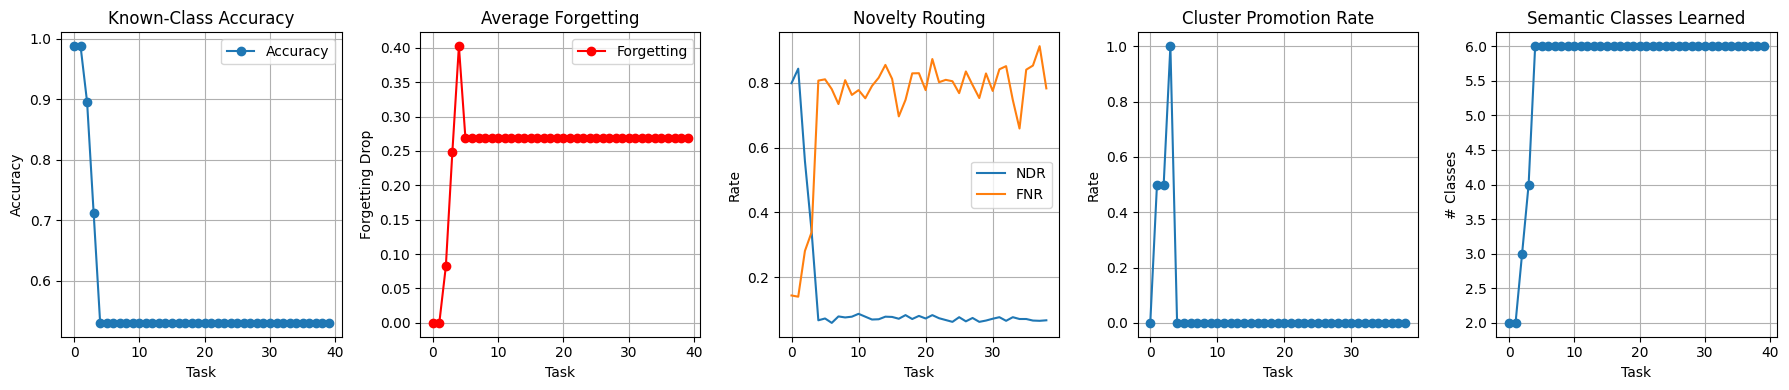

In [8]:
import os
import random
import torch
import torch.nn as nn
import torch.nn.functional as F
import numpy as np
import matplotlib.pyplot as plt
from collections import defaultdict, Counter
from torch.utils.data import DataLoader, TensorDataset
from sklearn.manifold import TSNE
import torchvision.transforms as T
from torchvision.models import resnet18
import hdbscan
import copy

# LabelBench Imports
from LabelBench.skeleton.dataset_skeleton import datasets as DATASET_REGISTRY

# ============================================================
# REPRODUCIBILITY LOCK
# ============================================================
def set_seed(seed=42):
    """Forces deterministic behavior for absolute reproducibility."""
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed(seed)
        torch.cuda.manual_seed_all(seed)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False
    os.environ['PYTHONHASHSEED'] = str(seed)

set_seed(42)

# ============================================================
# DIRECTORIES & CONFIGURATION
# ============================================================
BASE_DIR = "debug_raw_memory"

os.makedirs(BASE_DIR, exist_ok=True)
os.makedirs(f"{BASE_DIR}/tsne", exist_ok=True)
os.makedirs(f"{BASE_DIR}/tsne_supervised", exist_ok=True)
os.makedirs(f"{BASE_DIR}/tsne_finetune", exist_ok=True)
os.makedirs(f"{BASE_DIR}/hdbscan", exist_ok=True)
os.makedirs(f"{BASE_DIR}/drift", exist_ok=True)

# Assumes NUM_TASKS is defined in your dataloader cell
NUM_TASKS = 40
DEVICE = "cuda" if torch.cuda.is_available() else "cpu"

# Open-World Discovery Parameters
P = 1                          
TOPK_NOVELTY = 400             
MAX_NOVELTY_BUFFER = 2000      

# ============================================================
# RELAXED CLUSTER VALIDATION THRESHOLDS
# ============================================================
ALPHA = 0.35              
BETA = 0.01               
DELTA = 15                
MIN_CLUSTER_SIZE = 150    

CIFAR10_LABELS = {
    0: "airplane", 1: "automobile", 2: "bird", 3: "cat",
    4: "deer", 5: "dog", 6: "frog", 7: "horse",
    8: "ship", 9: "truck"
}

# ============================================================
# MODEL DEFINITION (COSINE CLASSIFIER + ARCFACE)
# ============================================================
class CNN(nn.Module):
    def __init__(self, num_classes):
        super().__init__()
        base = resnet18(weights='DEFAULT')
        
        base.conv1 = nn.Conv2d(3, 64, kernel_size=3, stride=1, padding=1, bias=False)
        base.maxpool = nn.Identity()
        
        self.encoder = nn.Sequential(*list(base.children())[:-1])
        self.embed = nn.Linear(512, 512)
        self.classifier = nn.Linear(512, num_classes, bias=False)
        self.scale = 20.0  

    def expand_head(self, new_classes):
        old_w = self.classifier.weight.data.clone()
        old_n = old_w.shape[0]
        new_classifier = nn.Linear(512, new_classes, bias=False).to(old_w.device)
        new_classifier.weight.data[:old_n] = old_w
        self.classifier = new_classifier

    def forward(self, x, labels=None):
        z = self.encoder(x)
        z = z.view(z.size(0), -1)
        z = self.embed(z)
            
        z = F.normalize(z, dim=1)
        W = F.normalize(self.classifier.weight, dim=1)
        cosine = torch.matmul(z, W.t())
    
        if labels is not None: 
            m = 0.2 
            theta = torch.acos(torch.clamp(cosine, -1+1e-7, 1-1e-7))
            target_logits = torch.cos(theta + m)
            one_hot = F.one_hot(labels, num_classes=W.size(0)).float()
            logits = cosine * (1 - one_hot) + target_logits * one_hot
        else:
            logits = cosine
    
        logits = logits * self.scale
        return logits, z

# ============================================================
# CENTROID DRIFT TRACKER
# ============================================================
class DebugCentroidTracker:
    def __init__(self):
        self.reference = {}
        self.history = defaultdict(list)

    def compute_centroids(self, model, memory):
        model.eval()
        centroids = {}
        with torch.no_grad():
            for cls, Xs in memory.items():
                if len(Xs) == 0: continue
                X = torch.stack([x for x, _ in Xs]).to(DEVICE)
                _, Z = model(X)
                mu = F.normalize(Z.mean(0), dim=0)
                centroids[cls] = mu.detach().cpu()
        return centroids

    def snapshot(self, model, memory):
        self.reference = self.compute_centroids(model, memory)

    def measure_drift(self, model, memory, epoch, tag=""):
        current = self.compute_centroids(model, memory)
        for cls in self.reference:
            if cls in current:
                drift = 1 - torch.dot(self.reference[cls], current[cls])
                self.history[(tag, cls)].append(drift.item())
                with open(f"{BASE_DIR}/drift/{tag}.txt", "a") as f:
                    f.write(f"Epoch {epoch} Class {cls}: {drift:.4f}\n")

    def plot_drift(self, tag):
        for (t, cls), values in self.history.items():
            if t == tag: plt.plot(values, label=f"class {cls}")
        plt.legend()
        plt.title(f"Centroid Drift {tag}")
        plt.xlabel("Checkpoint")
        plt.ylabel("1 - cosine similarity")
        plt.grid(True)
        plt.savefig(f"{BASE_DIR}/drift/{tag}_plot.png")
        plt.close()

# ============================================================
# MEMORY BUFFER (HERDING + BALANCED SAMPLING)
# ============================================================
class MemoryBuffer:
    def __init__(self, max_per_class=400):
        self.data = defaultdict(list)
        self.max_per_class = max_per_class
        self.aug = T.Compose([
            T.RandomCrop(32, padding=4),
            T.RandomHorizontalFlip()
        ])

    @torch.no_grad()
    def build_memory_herding(self, X_all, y_label, model):
        model.eval()
        logits_all, Z_all = [], []
        
        for i in range(0, len(X_all), 128):
            batch = X_all[i:i+128].to(DEVICE)
            logits, z = model(batch)
            logits_all.append(logits.cpu())
            Z_all.append(z.cpu())
            
        logits_all = torch.cat(logits_all)
        Z_all = torch.cat(Z_all)

        class_mean = F.normalize(Z_all.mean(0), dim=0)
        selected_idx = []
        features = Z_all.clone()

        for k in range(min(self.max_per_class, len(X_all))):
            if k > 0:
                S = Z_all[selected_idx].sum(0)
            else:
                S = torch.zeros_like(class_mean)
            
            target = (k + 1) * class_mean - S
            distances = torch.norm(features - target, dim=1)
            
            for idx in selected_idx:
                distances[idx] = float('inf')
            
            best = distances.argmin().item()
            selected_idx.append(best)

        self.data[int(y_label)] = []
        for idx in selected_idx:
            self.data[int(y_label)].append((X_all[idx].detach().cpu(), logits_all[idx].detach().cpu()))
    
    def get(self): return self.data

    def sample_balanced(self, batch_size, model):
        classes = list(self.data.keys())
        if not classes: return None, None, None
        
        samples_per_class = max(1, batch_size // len(classes))
        X_mem, Y_mem, L_mem = [], [], []
        current_dim = model.classifier.out_features
        
        for cls in classes:
            samples = self.data[cls]
            if len(samples) == 0: continue
            
            replace = len(samples) < samples_per_class
            idx = np.random.choice(len(samples), samples_per_class, replace=replace)
            
            for i in idx:
                x, logit = samples[i]
                if logit.shape[0] < current_dim:
                    padded = torch.zeros(current_dim)
                    padded[:logit.shape[0]] = logit
                    logit = padded
                X_mem.append(x)
                Y_mem.append(cls)
                L_mem.append(logit)
                
        if not X_mem: return None, None, None
        
        X_tensor = torch.stack(X_mem)
        X_tensor = self.aug(X_tensor) 
        return X_tensor, torch.tensor(Y_mem), torch.stack(L_mem)

# ============================================================
# HYPERSPHERE NOVELTY DETECTOR
# ============================================================
class HypersphereNovelty:
    def __init__(self, q=0.90):
        self.q = q
        self.mu, self.r = {}, {}

    def update(self, memory, model):
        self.mu, self.r = {}, {}
        for k, X_tuples in memory.items():
            if len(X_tuples) == 0: continue
            X = torch.stack([x for x, _ in X_tuples]).to(DEVICE)
            with torch.no_grad(): 
                _, Z = model(X)
            mu = F.normalize(Z.mean(0), dim=0)
            d = 1 - torch.matmul(Z, mu)
            self.mu[k] = mu
            self.r[k] = torch.quantile(d, self.q)

    def score(self, z):
        if not self.mu: return torch.tensor(0.0)
        return min([(1 - torch.dot(z, self.mu[k].to(z.device))) - self.r[k].to(z.device) for k in self.mu])

# ============================================================
# TRAINING HELPERS (SUPERVISED & CL FINETUNING)
# ============================================================
def train_supervised(model, loader, test_loader, task_id):
    opt = torch.optim.Adam(model.parameters(), lr=1e-4, weight_decay=1e-4)
    model.train()
    
    aug = T.Compose([
        T.RandomCrop(32, padding=4), 
        T.RandomHorizontalFlip()
    ])
    
    for epoch in range(30):
        if epoch % 5 == 0:
            visualize_epoch_tsne(model, test_loader, task_id, epoch, known_semantics=set(semantic_to_internal.keys()), phase="supervised")
        for x, y in loader:
            x, y = x.to(DEVICE), y.argmax(1).to(DEVICE)
            x = aug(x)
            loss = F.cross_entropy(model(x, y)[0], y)
            opt.zero_grad()
            loss.backward()
            opt.step()

def finetune(model, memory, X_new, new_label, task_id, test_loader): 
    old_model = copy.deepcopy(model).eval()
    for p in old_model.parameters(): p.requires_grad = False 

    debug_tracker = DebugCentroidTracker()
    debug_tracker.snapshot(model, memory.data)
    
    model.train()
    aug = T.Compose([T.RandomCrop(32, padding=4), T.RandomHorizontalFlip()])
    
    Y_new = torch.full((len(X_new),), new_label, dtype=torch.long)
    loader = DataLoader(TensorDataset(X_new, Y_new), batch_size=32, shuffle=True)

    for p in model.parameters(): p.requires_grad = True
        
    opt = torch.optim.Adam(model.parameters(), lr=5e-5, weight_decay=1e-4)

    visualize_epoch_tsne(model, test_loader, task_id, epoch="before", known_semantics=set(semantic_to_internal.keys()), phase="finetune")

    for epoch in range(15):
        for xb, yb in loader:
            xb = aug(xb) 
            X_mem, Y_mem, L_mem = memory.sample_balanced(32, model)

            if X_mem is not None:
                xb = torch.cat([xb, X_mem], dim=0)
                yb = torch.cat([yb, Y_mem], dim=0)

            xb, yb = xb.to(DEVICE), yb.to(DEVICE)
            
            logits_margin, Z = model(xb, yb)
            loss_ce = F.cross_entropy(logits_margin, yb)
            
            if X_mem is not None:
                pure_logits, _ = model(xb) 
                logits_mem = pure_logits[-len(X_mem):]
                loss_der = F.mse_loss(logits_mem, L_mem.to(DEVICE))
            else:
                loss_der = torch.tensor(0.0, device=DEVICE)

            with torch.no_grad(): 
                logits_old, Z_old = old_model(xb)

            loss_feat = (1 - F.cosine_similarity(Z, Z_old)).mean()
            loss = loss_ce + 0.5 * loss_der + 1.0 * loss_feat
            
            opt.zero_grad()
            loss.backward()
            opt.step()

        if epoch % 5 == 0:
            visualize_epoch_tsne(model, test_loader, task_id, epoch, known_semantics=set(semantic_to_internal.keys()), phase="finetune")
            debug_tracker.measure_drift(model, memory.data, epoch, tag=f"FT_Task{task_id}")

    model.eval()
    return debug_tracker

# ============================================================
# TSNE VISUALIZATIONS
# ============================================================
def visualize_tsne(model, loader, task_id, known_semantics, tag=""):
    model.eval()
    Z_all, Y_all = [], []
    with torch.no_grad():
        for x, y in loader:
            _, z = model(x.to(DEVICE))
            y = y.argmax(1)
            mask = torch.tensor([int(label.item()) in known_semantics for label in y])
            if mask.sum() > 0: 
                Z_all.append(z[mask].cpu())
                Y_all.append(y[mask].cpu())
    if not Z_all: return
    
    Z_all, Y_all = torch.cat(Z_all).numpy(), torch.cat(Y_all).numpy()
    n_samples = len(Z_all)
    
    if n_samples < 2: return 
    
    if n_samples > 3000: 
        idx = np.random.choice(n_samples, 3000, replace=False)
        Z_all, Y_all = Z_all[idx], Y_all[idx]
        n_samples = 3000
    
    perp = min(30, n_samples - 1)
    tsne = TSNE(n_components=2, perplexity=perp, metric="cosine", random_state=42, init="pca")
    Z_2d = tsne.fit_transform(Z_all)
    
    plt.figure(figsize=(7,6))
    for label in sorted(np.unique(Y_all)):
        plt.scatter(Z_2d[Y_all == label, 0], Z_2d[Y_all == label, 1], s=12, alpha=0.6, label=CIFAR10_LABELS[int(label)])
    plt.title(f"Task {task_id} ({tag})")
    plt.legend(fontsize=8)
    plt.grid(True)
    plt.tight_layout()
    filename = f"task_{task_id}_{tag}" if tag else f"task_{task_id}"
    plt.savefig(f"{BASE_DIR}/tsne/{filename}.png")
    plt.close()

def visualize_epoch_tsne(model, test_loader, task_id, epoch, known_semantics, phase="supervised"):
    model.eval()
    Z_all, Y_all = [], []
    with torch.no_grad():
        for x, y in test_loader:
            _, z = model(x.to(DEVICE))
            y = y.argmax(1)
            mask = torch.tensor([int(label.item()) in known_semantics for label in y])
            if mask.sum() > 0: 
                Z_all.append(z[mask].cpu())
                Y_all.append(y[mask].cpu())
    if not Z_all: return
    
    Z_all, Y_all = torch.cat(Z_all).numpy(), torch.cat(Y_all).numpy()
    n_samples = len(Z_all)
    if n_samples < 2: return
    
    if n_samples > 3000: 
        idx = np.random.choice(n_samples, 3000, replace=False)
        Z_all, Y_all = Z_all[idx], Y_all[idx]
        n_samples = 3000
        
    perp = min(30, n_samples - 1)
    tsne = TSNE(n_components=2, perplexity=perp, metric="cosine", random_state=42, init="pca")
    Z_2d = tsne.fit_transform(Z_all)
    
    plt.figure(figsize=(7,6))
    for label in sorted(np.unique(Y_all)):
        plt.scatter(Z_2d[Y_all == label, 0], Z_2d[Y_all == label, 1], s=12, alpha=0.6, label=CIFAR10_LABELS[int(label)])
    plt.title(f"{phase} | Task {task_id} | Epoch {epoch}")
    plt.legend(fontsize=8)
    plt.grid(True)
    plt.tight_layout()
    save_path = f"{BASE_DIR}/tsne_{phase}/task{task_id}_epoch{epoch}.png"
    plt.savefig(save_path)
    plt.close()

def visualize_clusters(Z, labels, task_id):
    n_samples = len(Z)
    if n_samples < 2: 
        print(f"⚠️  [DEBUG] Only {n_samples} points in buffer. Skipping cluster visualization.")
        return
        
    perp = min(30, n_samples - 1)
    tsne = TSNE(n_components=2, perplexity=perp, random_state=42)
    Z_2d = tsne.fit_transform(Z)

    plt.figure(figsize=(6,5))
    for cid in set(labels):
        mask = labels == cid
        if cid == -1:
            plt.scatter(Z_2d[mask,0], Z_2d[mask,1], s=10, alpha=0.3, label="Noise")
        else:
            plt.scatter(Z_2d[mask,0], Z_2d[mask,1], s=15, alpha=0.7, label=f"Cluster {cid}")

    plt.legend()
    plt.title(f"Cluster Structure Task {task_id}")
    plt.grid(True)
    plt.savefig(f"{BASE_DIR}/hdbscan/task_{task_id}.png")
    plt.close()

# ============================================================
# EVALUATION HELPER FOR ACCURACY & FORGETTING
# ============================================================
def evaluate_class_metrics(model, test_ds, semantic_to_internal, t, class_accuracies):
    correct_per_class = defaultdict(int)
    total_per_class = defaultdict(int)
    
    model.eval()
    with torch.no_grad():
        for x_test, y_test in DataLoader(test_ds, batch_size=128):
            x_test = x_test.to(DEVICE)
            y_test = y_test.argmax(1).to(DEVICE)
            logits, _ = model(x_test)
            preds = logits.argmax(1)
            
            for i in range(len(y_test)):
                sem = int(y_test[i])
                if sem in semantic_to_internal:
                    internal_gt = semantic_to_internal[sem]
                    total_per_class[sem] += 1
                    if preds[i].item() == internal_gt:
                        correct_per_class[sem] += 1

    current_class_accs = {}
    total_known_correct = 0
    total_known_eval = 0
    
    for sem in semantic_to_internal.keys():
        total_known_correct += correct_per_class[sem]
        total_known_eval += total_per_class[sem]
        current_class_accs[sem] = correct_per_class[sem] / max(total_per_class[sem], 1)
        
    class_accuracies[t] = current_class_accs
    
    kca = total_known_correct / max(total_known_eval, 1)
    
    if t > 0:
        forgetting_list = []
        for sem in current_class_accs.keys():
            past_accs = [class_accuracies[k].get(sem, None) for k in range(t) if k in class_accuracies]
            past_accs = [a for a in past_accs if a is not None]
            if past_accs:
                max_past = max(past_accs)
                forgetting = max_past - current_class_accs[sem]
                forgetting_list.append(forgetting)
        avg_forg = np.mean(forgetting_list) if forgetting_list else 0.0
    else:
        avg_forg = 0.0
        
    return kca, avg_forg, current_class_accs

# ============================================================
# METRIC STORAGE & INITIALIZATION
# ============================================================

task_kca, task_ndr, task_fnr, task_cpr = [], [], [], []
average_forgetting = [] 
class_accuracies = {}   
learned_classes_over_time = []
promoted_classes_log = []

TASKS = [f"splitcifar10_{i}" for i in range(NUM_TASKS)]

model = CNN(num_classes=2).to(DEVICE)
memory = MemoryBuffer(max_per_class=200)
detector = HypersphereNovelty()

novelty_buffer = []

semantic_to_internal = {0: 0, 1: 1}
internal_to_semantic = {0: 0, 1: 1}
known_classes = 2

_, dataset_fn = DATASET_REGISTRY[TASKS[0]]
_, test_ds, *_ = dataset_fn("./data")
print("\n[TSNE] Before Training")
visualize_tsne(model, DataLoader(test_ds, batch_size=128, shuffle=False), -1, known_semantics=set(semantic_to_internal.keys()))

# ============================================================
# MAIN OPEN-WORLD CONTINUAL LEARNING LOOP
# ============================================================

for t, task in enumerate(TASKS):

    print(f"\n{'='*20} 🚀 TASK {t} {'='*20}")

    _, dataset_fn = DATASET_REGISTRY[task]
    train_ds, test_ds, *_ = dataset_fn("./data")
    loader = DataLoader(train_ds, batch_size=64, shuffle=True) 

    all_semantics = []
    for _, y in loader: all_semantics.extend(y.argmax(1).tolist())
    unique_semantics = list(set(all_semantics))
    class_names = [CIFAR10_LABELS[sem] for sem in unique_semantics]
    print(f"📦 [STREAM] Task {t} stream contains class(es): {class_names} (Label IDs: {unique_semantics})")
    print(f"📊 [STREAM] Total images in this chunk: {len(train_ds)}")

    if t == 0:
        print("🎓 [INIT] Running supervised baseline on Task 0...")
        train_supervised(model, loader, DataLoader(test_ds, batch_size=128, shuffle=False), t)

        for cls in [0, 1]:
            Xc = torch.cat([x[y.argmax(1) == cls] for x, y in loader])
            memory.build_memory_herding(Xc, cls, model)

        detector.update(memory.get(), model)
        visualize_tsne(model, DataLoader(test_ds, batch_size=128, shuffle=False), t, known_semantics=set(semantic_to_internal.keys()))
        
        learned_classes_over_time.append({CIFAR10_LABELS[0], CIFAR10_LABELS[1]})
        print(f"✅ [INIT COMPLETE] Known classes: {learned_classes_over_time[-1]}")
        
        acc, avg_forg, current_class_accs = evaluate_class_metrics(model, test_ds, semantic_to_internal, t, class_accuracies)
        task_kca.append(acc)
        average_forgetting.append(avg_forg)
        
        print(f"📈 [METRIC] Known-Class Acc: {acc:.3f} | Avg Forgetting: {avg_forg:.3f}")
        for sem, c_acc in current_class_accs.items():
            print(f"   ➔ Class '{CIFAR10_LABELS[sem]}' Acc: {c_acc:.3f}")

        promoted_classes_log.append({
            "task": 0,
            "semantic": f"{CIFAR10_LABELS[0]} & {CIFAR10_LABELS[1]}",
            "purity": 1.0,
            "stats": "Base Supervised Initialization",
            "acc": acc
        })
        
        continue

    model.eval()
    novelty_candidates = []
    novel, false_novel, total = 0, 0, 0

    with torch.no_grad():
        for x, y in loader:
            _, z = model(x.to(DEVICE))
            y = y.argmax(1)

            scores = [detector.score(z[i]).item() for i in range(len(z))]
            
            # --- OPEN WORLD FIX 1: Dynamic Absolute Thresholding ---
            # Replaced rigid np.percentile which forces false positives/negatives in mixed batches
            thr = 0.0

            for i in range(len(z)):
                total += 1
                if scores[i] > thr:
                    novelty_candidates.append((scores[i], x[i].cpu(), y[i].item()))
                    novel += 1
                    if y[i].item() in semantic_to_internal:
                        false_novel += 1

    task_ndr.append(novel / max(total, 1))
    task_fnr.append(false_novel / max(novel, 1))

    print(f"🔍 [NOVELTY] Flagged Novel: {novel}/{total} | False Novelty (Knowns flagged): {false_novel}")

    novelty_candidates.sort(reverse=True, key=lambda x: x[0])
    novelty_buffer.extend([(img, y) for _, img, y in novelty_candidates[:TOPK_NOVELTY]])
    novelty_buffer = novelty_buffer[-MAX_NOVELTY_BUFFER:]

    if t % P == 0:
        print(f"\n🧠 [CLUSTERING] Running HDBSCAN on novelty buffer (Size: {len(novelty_buffer)})...")
        
        if len(novelty_buffer) < 2:
            print("  ⚠️  [DEBUG] Not enough samples to cluster. Skipping...")
            task_cpr.append(0.0)
            continue
        
        Z = []
        with torch.no_grad():
            for img, _ in novelty_buffer:
                _, z = model(img.unsqueeze(0).to(DEVICE))
                Z.append(z.squeeze().cpu().numpy())

        Z = np.stack(Z)
        
        labels = hdbscan.HDBSCAN(metric='euclidean', min_cluster_size=40).fit_predict(Z)
        
        visualize_clusters(Z, labels, t)
        
        new_buffer = []
        found, promoted = 0, 0

        for cid in sorted(set(labels)):
            idxs = np.where(labels == cid)[0]

            if cid == -1:
                print(f"  🗑️  [CLUSTER -1] NOISE: Found {len(idxs)} noise samples.")
                for i in idxs: new_buffer.append(novelty_buffer[i])
                continue

            found += 1
            Xc = torch.stack([novelty_buffer[i][0] for i in idxs])

            with torch.no_grad():
                _, Zc = model(Xc.to(DEVICE))

            mu = F.normalize(Zc.mean(0), dim=0)
            n = len(idxs)
            S_intra = torch.mean(1 - torch.matmul(Zc, mu))

            if len(detector.mu) > 0:
                S_known = min([1 - torch.dot(mu, detector.mu[k].to(mu.device)) for k in detector.mu])
            else:
                S_known = torch.tensor(1.0)

            density = n / (S_intra.item() + 1e-6)
            margin = S_known - S_intra
            
            labels_true = [novelty_buffer[i][1] for i in idxs]
            sem_label, cnt = Counter(labels_true).most_common(1)[0]
            purity = cnt / len(labels_true)

            if sem_label in semantic_to_internal:
                print(f"\n  ⚠️  [CLUSTER {cid}] SKIPPED: Dominant class '{CIFAR10_LABELS[sem_label]}' is already known.")
                continue

            cond_intra = S_intra.item() <= ALPHA
            cond_density = density >= DELTA
            cond_known = S_known.item() >= BETA
            cond_margin = margin.item() > -0.10
            cond_size = n >= MIN_CLUSTER_SIZE

            print(f"\n  📊 [CLUSTER {cid} EVALUATION] Dominant: '{CIFAR10_LABELS[sem_label]}' (Purity: {purity:.2f})")
            print(f"     ➔ Size:    {n:3d}   (Req: >= {MIN_CLUSTER_SIZE:2d})   {'✅' if cond_size else '❌'}")
            print(f"     ➔ S_intra: {S_intra.item():.3f} (Req: <= {ALPHA:.2f}) {'✅' if cond_intra else '❌'}")
            print(f"     ➔ S_known: {S_known.item():.3f} (Req: >= {BETA:.2f}) {'✅' if cond_known else '❌'}")
            print(f"     ➔ Density: {density:.1f} (Req: >= {DELTA})   {'✅' if cond_density else '❌'}")
            print(f"     ➔ Margin:  {margin.item():.3f} (Req: > -0.10) {'✅' if cond_margin else '❌'}")

            if cond_intra and cond_density and cond_known and cond_margin and cond_size:
                promoted += 1
                new_label = known_classes

                semantic_to_internal[sem_label] = new_label
                internal_to_semantic[new_label] = sem_label
                known_classes += 1

                model.expand_head(known_classes)
                model.to(DEVICE)

                print(f"     🎉 [PROMOTION SUCCESS] -> Preparing to Finetune '{CIFAR10_LABELS[sem_label]}'...")
                debug_tracker = finetune(model, memory, Xc, new_label, t, DataLoader(test_ds, batch_size=128, shuffle=False))
                debug_tracker.plot_drift(f"FT_Task{t}")
                
                memory.build_memory_herding(Xc, new_label, model)
                detector.update(memory.get(), model)

                promoted_classes_log.append({
                    "task": t,
                    "semantic": CIFAR10_LABELS[sem_label],
                    "purity": purity,
                    "stats": f"size={n}, S_intra={S_intra.item():.3f}, S_known={S_known.item():.3f}, dens={density:.1f}, margin={margin.item():.3f}",
                    "acc": None
                })

                print(f"     ✨ [LEARNED] -> Network successfully adapted to '{CIFAR10_LABELS[sem_label]}'")
            else:
                print(f"     🛑 [PROMOTION FAILED] -> Conditions not met. Retaining samples in buffer.")
                for i in idxs: new_buffer.append(novelty_buffer[i])

        novelty_buffer = new_buffer
        task_cpr.append(promoted / max(found, 1))
    else:
        task_cpr.append(0.0)

    # --- OPEN WORLD FIX 2: Continuous Buffer Operation ---
    # Removed the hard flush (if t > 0 and t % 5 == 0: novelty_buffer = []) 
    # True open world streams do not have predictable clean breaks between concepts.

    learned_classes_over_time.append(
        set(learned_classes_over_time[-1]) if len(learned_classes_over_time) > 0 else set()
    )

    for p in promoted_classes_log:
        if p["task"] == t and p["semantic"] not in learned_classes_over_time[-1]:
            learned_classes_over_time[-1].add(p["semantic"])

    acc, avg_forg, current_class_accs = evaluate_class_metrics(model, test_ds, semantic_to_internal, t, class_accuracies)
    task_kca.append(acc)
    average_forgetting.append(avg_forg)
    
    print(f"📈 [METRIC] Known-Class Acc: {acc:.3f} | Avg Forgetting: {avg_forg:.3f}")
    for sem, c_acc in current_class_accs.items():
        print(f"   ➔ Class '{CIFAR10_LABELS[sem]}' Acc: {c_acc:.3f}")

    visualize_tsne(model, DataLoader(test_ds, batch_size=128, shuffle=False), t, known_semantics=set(semantic_to_internal.keys()))

    for p in promoted_classes_log:
        if p["task"] == t and p.get("acc") is None:
            p["acc"] = acc

# ============================================================
# FINAL SUMMARY & VISUALIZATION
# ============================================================

print("\n" + "="*40)
print("🏆 FINAL DISCOVERY SUMMARY")
print("="*40)

if len(learned_classes_over_time) > 0:
    print(f"Initial classes: {learned_classes_over_time[0]}")
    print(f"Final learned classes: {learned_classes_over_time[-1]}")

print("\nPromoted classes timeline:")
for p in promoted_classes_log:
    if p["task"] == 0:
        print(f"Task {p['task']:02d} → {p['semantic']:<22} (Init   | Acc: {p['acc']:.3f} | {p['stats']})")
    else:
        print(f"Task {p['task']:02d} → {p['semantic']:<22} (purity={p['purity']:.2f} | Acc: {p['acc']:.3f} | stats: {p['stats']})")

print("\n" + "="*40)
print("📊 TASK-BY-TASK ACCURACY & FORGETTING TIMELINE")
print("="*40)
for task_idx in range(NUM_TASKS):
    if task_idx in class_accuracies:
        acc_str = ", ".join([f"{CIFAR10_LABELS[sem]}: {class_accuracies[task_idx][sem]:.3f}" for sem in class_accuracies[task_idx]])
        print(f"Task {task_idx:02d} | KCA: {task_kca[task_idx]:.3f} | Avg Forgetting: {average_forgetting[task_idx]:.3f} | Class Accs: [{acc_str}]")

plt.figure(figsize=(18,4))

plt.subplot(1,5,1)
plt.plot(task_kca, marker='o', label="Accuracy")
plt.title("Known-Class Accuracy")
plt.xlabel("Task")
plt.ylabel("Accuracy")
plt.grid(True)
plt.legend()

plt.subplot(1,5,2)
plt.plot(average_forgetting, marker='o', color='red', label="Forgetting")
plt.title("Average Forgetting")
plt.xlabel("Task")
plt.ylabel("Forgetting Drop")
plt.grid(True)
plt.legend()

plt.subplot(1,5,3)
plt.plot(task_ndr, label="NDR")
plt.plot(task_fnr, label="FNR")
plt.title("Novelty Routing")
plt.xlabel("Task")
plt.ylabel("Rate")
plt.legend()
plt.grid(True)

plt.subplot(1,5,4)
plt.plot(task_cpr, marker='o')
plt.title("Cluster Promotion Rate")
plt.xlabel("Task")
plt.ylabel("Rate")
plt.grid(True)

plt.subplot(1,5,5)
plt.plot([len(set_) for set_ in learned_classes_over_time], marker='o')
plt.title("Semantic Classes Learned")
plt.xlabel("Task")
plt.ylabel("# Classes")
plt.grid(True)

plt.tight_layout()
plt.show()

## Open world settings modified introduction of 2-3 new classes at a time
### Dataloader (Exhaust + Replay)

In [3]:
import os
# Must be set BEFORE importing any other libraries
os.environ['PYTHONHASHSEED'] = '42'
os.environ['CUBLAS_WORKSPACE_CONFIG'] = ':4096:8'

import torch
import torch.nn.functional as F
from torchvision import datasets as tv_datasets, transforms
from torch.utils.data import Dataset
from LabelBench.skeleton.dataset_skeleton import register_dataset, LabelType, TransformDataset
import numpy as np
import random

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
torch.cuda.manual_seed_all(SEED)
torch.backends.cudnn.deterministic = True
torch.backends.cudnn.benchmark = False
torch.use_deterministic_algorithms(True, warn_only=True)

NUM_TASKS = 40   

# ------------------------------------------------------------
# Dataset wrapper
# ------------------------------------------------------------
class CIFARStream(Dataset):
    def __init__(self, base_ds, indices):
        self.base_ds = base_ds      
        self.indices = indices      

    def __len__(self):
        return len(self.indices)

    def __getitem__(self, idx):
        x, y = self.base_ds[self.indices[idx]]
        return x, y

def one_hot(y, n=10):
    return F.one_hot(torch.tensor(y), num_classes=n).float()

@register_dataset("splitcifar10", LabelType.MULTI_CLASS)
def get_splitcifar10(_):
    raise RuntimeError("Use splitcifar10_<id>")

# ------------------------------------------------------------
# Build task stream ONCE (WAY 1: Exhaust + Replay)
# ------------------------------------------------------------
base_train_global = tv_datasets.CIFAR10(root="./data", train=True, download=True)
targets = np.array(base_train_global.targets)

# Group indices by class
class_indices = {c: np.where(targets == c)[0] for c in range(10)}

rng = np.random.default_rng(SEED)
for c in range(10):
    rng.shuffle(class_indices[c])

stream_splits = {}
for t in range(1, NUM_TASKS):
    stream_splits[t] = []
    
    # 1. Add 100 Reminders for previously exhausted classes
    if 1 <= t <= 13:
        reminders = [0, 1]
    elif 14 <= t <= 26:
        reminders = [0, 1, 2, 3]
    elif 27 <= t <= 39:
        reminders = [0, 1, 2, 3, 4, 5, 6]
    else:
        reminders = []
        
    for c in reminders:
        stream_splits[t].extend(rng.choice(class_indices[c], 100, replace=False))
        
    # 2. Add New Wave active classes (exhausting ~5000 images over 13 tasks)
    if 1 <= t <= 13:
        stream_splits[t].extend(np.array_split(class_indices[2], 13)[t-1])
        stream_splits[t].extend(np.array_split(class_indices[3], 13)[t-1])
    elif 14 <= t <= 26:
        stream_splits[t].extend(np.array_split(class_indices[4], 13)[t-14])
        stream_splits[t].extend(np.array_split(class_indices[5], 13)[t-14])
        stream_splits[t].extend(np.array_split(class_indices[6], 13)[t-14])
    elif 27 <= t <= 39:
        stream_splits[t].extend(np.array_split(class_indices[7], 13)[t-27])
        stream_splits[t].extend(np.array_split(class_indices[8], 13)[t-27])
        stream_splits[t].extend(np.array_split(class_indices[9], 13)[t-27])
        
    rng.shuffle(stream_splits[t])

# ------------------------------------------------------------
# Register each task dynamically (FIXED LOGIC)
# ------------------------------------------------------------
for split_id in range(NUM_TASKS):

    @register_dataset(f"splitcifar10_{split_id}", LabelType.MULTI_CLASS)
    def _make_split(data_dir, split_id=split_id):

        tf = transforms.Compose([transforms.ToTensor()])
        base_train = tv_datasets.CIFAR10(root=data_dir, train=True, download=True)
        base_test  = tv_datasets.CIFAR10(root=data_dir, train=False, download=True)
        
        # ----------------------------------------------------
        # OPEN WORLD LOGIC: 
        # Task 0 gets knowns. Everything else gets the stream.
        # ----------------------------------------------------
        if split_id == 0:
            indices = [i for i,(x,y) in enumerate(base_train) if y in [0,1]]
        else:
            indices = stream_splits[split_id]

        train_ds = CIFARStream(base_train, indices)

        train_ds = TransformDataset(
            train_ds,
            transform=tf,
            target_transform=lambda y: one_hot(y,10)
        )

        test_ds = TransformDataset(
            base_test,
            transform=tf,
            target_transform=lambda y: one_hot(y,10)
        )

        return train_ds, test_ds, test_ds, None, None, None, 10, [str(i) for i in range(10)]

100%|██████████| 170M/170M [00:02<00:00, 82.5MB/s] 


### Model training pipeline

/usr/local/lib/python3.12/dist-packages/hdbscan/robust_single_linkage_.py:175: SyntaxWarning: invalid escape sequence '\{'
  $max \{ core_k(a), core_k(b), 1/\alpha d(a,b) \}$.


Downloading: "https://download.pytorch.org/models/resnet18-f37072fd.pth" to /root/.cache/torch/hub/checkpoints/resnet18-f37072fd.pth


100%|██████████| 44.7M/44.7M [00:00<00:00, 160MB/s] 



[TSNE] Before Training

==================== 🚀 TASK 0 ====================
📦 [STREAM] Task 0 stream contains class(es): ['airplane', 'automobile'] (Label IDs: [0, 1])
📊 [STREAM] Total images in this chunk: 10000
🎓 [INIT] Running supervised baseline on Task 0...
✅ [INIT COMPLETE] Known classes: {'airplane', 'automobile'}
📈 [METRIC] Known-Class Acc: 0.984 | Avg Forgetting: 0.000
   ➔ Class 'airplane' Acc: 0.998
   ➔ Class 'automobile' Acc: 0.970

==================== 🚀 TASK 1 ====================
📦 [STREAM] Task 1 stream contains class(es): ['airplane', 'automobile', 'bird', 'cat'] (Label IDs: [0, 1, 2, 3])
📊 [STREAM] Total images in this chunk: 970
🔍 [NOVELTY] Flagged Novel: 813/970 | False Novelty (Knowns flagged): 125

🧠 [CLUSTERING] Running HDBSCAN on novelty buffer (Size: 400)...
  🗑️  [CLUSTER -1] NOISE: Found 400 noise samples.
📈 [METRIC] Known-Class Acc: 0.984 | Avg Forgetting: 0.000
   ➔ Class 'airplane' Acc: 0.998
   ➔ Class 'automobile' Acc: 0.970

==================== 🚀 TASK

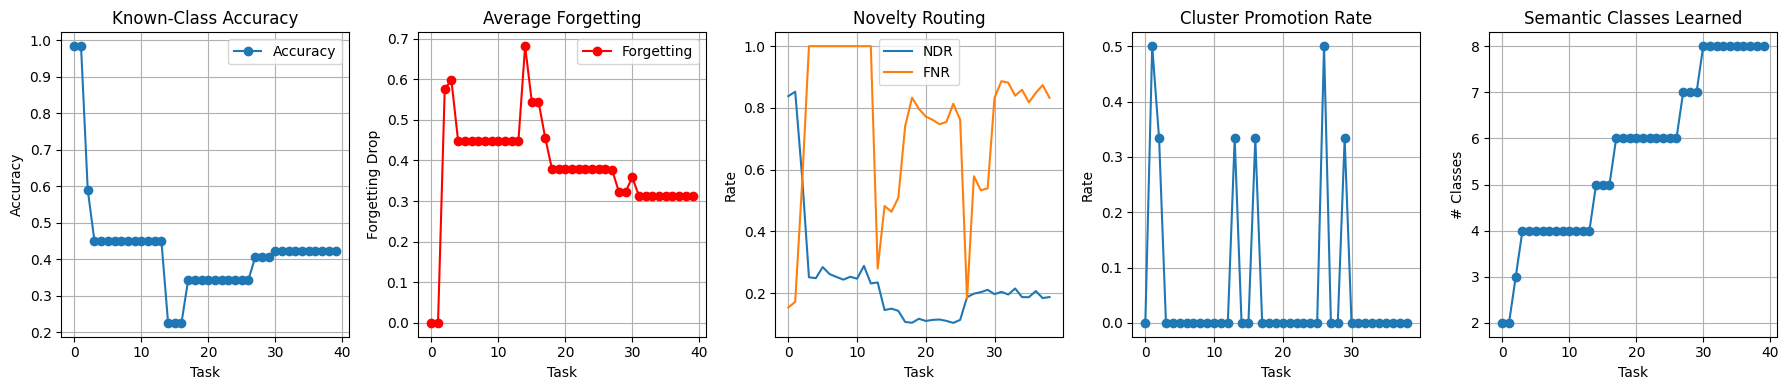

In [4]:
import os
# Must be set BEFORE importing any other libraries
os.environ['PYTHONHASHSEED'] = '42'
os.environ['CUBLAS_WORKSPACE_CONFIG'] = ':4096:8'

import random
import torch
import torch.nn as nn
import torch.nn.functional as F
import numpy as np
import matplotlib.pyplot as plt
from collections import defaultdict, Counter
from torch.utils.data import DataLoader, TensorDataset
from sklearn.manifold import TSNE
import torchvision.transforms as T
from torchvision.models import resnet18
import hdbscan
import copy

# LabelBench Imports
from LabelBench.skeleton.dataset_skeleton import datasets as DATASET_REGISTRY

# ============================================================
# REPRODUCIBILITY LOCK
# ============================================================
def set_seed(seed=42):
    """Forces deterministic behavior for absolute reproducibility."""
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed(seed)
        torch.cuda.manual_seed_all(seed)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False
    
    # Force PyTorch to use deterministic algorithms globally
    torch.use_deterministic_algorithms(True, warn_only=True)

set_seed(42)

# ============================================================
# DATALOADER GENERATOR FIX
# ============================================================
def seed_worker(worker_id):
    worker_seed = torch.initial_seed() % 2**32
    np.random.seed(worker_seed)
    random.seed(worker_seed)

g = torch.Generator()
g.manual_seed(42)

# ============================================================
# DIRECTORIES & CONFIGURATION (WAY 1 FOLDER)
# ============================================================
BASE_DIR = "way1_debug_raw_memory"

os.makedirs(BASE_DIR, exist_ok=True)
os.makedirs(f"{BASE_DIR}/tsne", exist_ok=True)
os.makedirs(f"{BASE_DIR}/tsne_supervised", exist_ok=True)
os.makedirs(f"{BASE_DIR}/tsne_finetune", exist_ok=True)
os.makedirs(f"{BASE_DIR}/hdbscan", exist_ok=True)
os.makedirs(f"{BASE_DIR}/drift", exist_ok=True)

NUM_TASKS = 40
DEVICE = "cuda" if torch.cuda.is_available() else "cpu"

P = 1                          
TOPK_NOVELTY = 400             
MAX_NOVELTY_BUFFER = 2000      

ALPHA = 0.35              
BETA = 0.01               
DELTA = 15                
MIN_CLUSTER_SIZE = 150    

CIFAR10_LABELS = {
    0: "airplane", 1: "automobile", 2: "bird", 3: "cat",
    4: "deer", 5: "dog", 6: "frog", 7: "horse",
    8: "ship", 9: "truck"
}

# ============================================================
# MODEL DEFINITION (COSINE CLASSIFIER + ARCFACE)
# ============================================================
class CNN(nn.Module):
    def __init__(self, num_classes):
        super().__init__()
        base = resnet18(weights='DEFAULT')
        
        base.conv1 = nn.Conv2d(3, 64, kernel_size=3, stride=1, padding=1, bias=False)
        base.maxpool = nn.Identity()
        
        self.encoder = nn.Sequential(*list(base.children())[:-1])
        self.embed = nn.Linear(512, 512)
        self.classifier = nn.Linear(512, num_classes, bias=False)
        self.scale = 20.0  

    def expand_head(self, new_classes):
        old_w = self.classifier.weight.data.clone()
        old_n = old_w.shape[0]
        new_classifier = nn.Linear(512, new_classes, bias=False).to(old_w.device)
        new_classifier.weight.data[:old_n] = old_w
        self.classifier = new_classifier

    def forward(self, x, labels=None):
        z = self.encoder(x)
        z = z.view(z.size(0), -1)
        z = self.embed(z)
            
        z = F.normalize(z, dim=1)
        W = F.normalize(self.classifier.weight, dim=1)
        cosine = torch.matmul(z, W.t())
    
        if labels is not None: 
            m = 0.2 
            theta = torch.acos(torch.clamp(cosine, -1+1e-7, 1-1e-7))
            target_logits = torch.cos(theta + m)
            one_hot = F.one_hot(labels, num_classes=W.size(0)).float()
            logits = cosine * (1 - one_hot) + target_logits * one_hot
        else:
            logits = cosine
    
        logits = logits * self.scale
        return logits, z

# ============================================================
# CENTROID DRIFT TRACKER
# ============================================================
class DebugCentroidTracker:
    def __init__(self):
        self.reference = {}
        self.history = defaultdict(list)

    def compute_centroids(self, model, memory):
        model.eval()
        centroids = {}
        with torch.no_grad():
            for cls, Xs in memory.items():
                if len(Xs) == 0: continue
                X = torch.stack([x for x, _ in Xs]).to(DEVICE)
                _, Z = model(X)
                mu = F.normalize(Z.mean(0), dim=0)
                centroids[cls] = mu.detach().cpu()
        return centroids

    def snapshot(self, model, memory):
        self.reference = self.compute_centroids(model, memory)

    def measure_drift(self, model, memory, epoch, tag=""):
        current = self.compute_centroids(model, memory)
        for cls in self.reference:
            if cls in current:
                drift = 1 - torch.dot(self.reference[cls], current[cls])
                self.history[(tag, cls)].append(drift.item())
                with open(f"{BASE_DIR}/drift/{tag}.txt", "a") as f:
                    f.write(f"Epoch {epoch} Class {cls}: {drift:.4f}\n")

    def plot_drift(self, tag):
        for (t, cls), values in self.history.items():
            if t == tag: plt.plot(values, label=f"class {cls}")
        plt.legend()
        plt.title(f"Centroid Drift {tag}")
        plt.xlabel("Checkpoint")
        plt.ylabel("1 - cosine similarity")
        plt.grid(True)
        plt.savefig(f"{BASE_DIR}/drift/{tag}_plot.png")
        plt.close()

# ============================================================
# MEMORY BUFFER (HERDING + BALANCED SAMPLING)
# ============================================================
class MemoryBuffer:
    def __init__(self, max_per_class=400):
        self.data = defaultdict(list)
        self.max_per_class = max_per_class
        self.aug = T.Compose([
            T.RandomCrop(32, padding=4),
            T.RandomHorizontalFlip()
        ])

    @torch.no_grad()
    def build_memory_herding(self, X_all, y_label, model):
        model.eval()
        logits_all, Z_all = [], []
        
        for i in range(0, len(X_all), 128):
            batch = X_all[i:i+128].to(DEVICE)
            logits, z = model(batch)
            logits_all.append(logits.cpu())
            Z_all.append(z.cpu())
            
        logits_all = torch.cat(logits_all)
        Z_all = torch.cat(Z_all)

        class_mean = F.normalize(Z_all.mean(0), dim=0)
        selected_idx = []
        features = Z_all.clone()

        for k in range(min(self.max_per_class, len(X_all))):
            if k > 0:
                S = Z_all[selected_idx].sum(0)
            else:
                S = torch.zeros_like(class_mean)
            
            target = (k + 1) * class_mean - S
            distances = torch.norm(features - target, dim=1)
            
            for idx in selected_idx:
                distances[idx] = float('inf')
            
            best = distances.argmin().item()
            selected_idx.append(best)

        self.data[int(y_label)] = []
        for idx in selected_idx:
            self.data[int(y_label)].append((X_all[idx].detach().cpu(), logits_all[idx].detach().cpu()))
    
    def get(self): return self.data

    def sample_balanced(self, batch_size, model):
        classes = list(self.data.keys())
        if not classes: return None, None, None
        
        samples_per_class = max(1, batch_size // len(classes))
        X_mem, Y_mem, L_mem = [], [], []
        current_dim = model.classifier.out_features
        
        for cls in classes:
            samples = self.data[cls]
            if len(samples) == 0: continue
            
            replace = len(samples) < samples_per_class
            idx = np.random.choice(len(samples), samples_per_class, replace=replace)
            
            for i in idx:
                x, logit = samples[i]
                if logit.shape[0] < current_dim:
                    padded = torch.zeros(current_dim)
                    padded[:logit.shape[0]] = logit
                    logit = padded
                X_mem.append(x)
                Y_mem.append(cls)
                L_mem.append(logit)
                
        if not X_mem: return None, None, None
        
        X_tensor = torch.stack(X_mem)
        X_tensor = self.aug(X_tensor) 
        return X_tensor, torch.tensor(Y_mem), torch.stack(L_mem)

# ============================================================
# HYPERSPHERE NOVELTY DETECTOR
# ============================================================
class HypersphereNovelty:
    def __init__(self, q=0.90):
        self.q = q
        self.mu, self.r = {}, {}

    def update(self, memory, model):
        self.mu, self.r = {}, {}
        for k, X_tuples in memory.items():
            if len(X_tuples) == 0: continue
            X = torch.stack([x for x, _ in X_tuples]).to(DEVICE)
            with torch.no_grad(): 
                _, Z = model(X)
            mu = F.normalize(Z.mean(0), dim=0)
            d = 1 - torch.matmul(Z, mu)
            self.mu[k] = mu
            self.r[k] = torch.quantile(d, self.q)

    def score(self, z):
        if not self.mu: return torch.tensor(0.0)
        return min([(1 - torch.dot(z, self.mu[k].to(z.device))) - self.r[k].to(z.device) for k in self.mu])

# ============================================================
# TRAINING HELPERS (SUPERVISED & CL FINETUNING)
# ============================================================
def train_supervised(model, loader, test_loader, task_id):
    opt = torch.optim.Adam(model.parameters(), lr=1e-4, weight_decay=1e-4)
    model.train()
    
    aug = T.Compose([
        T.RandomCrop(32, padding=4), 
        T.RandomHorizontalFlip()
    ])
    
    for epoch in range(30):
        if epoch % 5 == 0:
            visualize_epoch_tsne(model, test_loader, task_id, epoch, known_semantics=set(semantic_to_internal.keys()), phase="supervised")
        for x, y in loader:
            x, y = x.to(DEVICE), y.argmax(1).to(DEVICE)
            x = aug(x)
            loss = F.cross_entropy(model(x, y)[0], y)
            opt.zero_grad()
            loss.backward()
            opt.step()

def finetune(model, memory, X_new, new_label, task_id, test_loader): 
    old_model = copy.deepcopy(model).eval()
    for p in old_model.parameters(): p.requires_grad = False 

    debug_tracker = DebugCentroidTracker()
    debug_tracker.snapshot(model, memory.data)
    
    model.train()
    aug = T.Compose([T.RandomCrop(32, padding=4), T.RandomHorizontalFlip()])
    
    Y_new = torch.full((len(X_new),), new_label, dtype=torch.long)
    # ADDED: seed_worker and generator to finetuning dataloader
    loader = DataLoader(
        TensorDataset(X_new, Y_new), 
        batch_size=32, 
        shuffle=True, 
        worker_init_fn=seed_worker, 
        generator=g
    )

    for p in model.parameters(): p.requires_grad = True
        
    opt = torch.optim.Adam(model.parameters(), lr=5e-5, weight_decay=1e-4)

    visualize_epoch_tsne(model, test_loader, task_id, epoch="before", known_semantics=set(semantic_to_internal.keys()), phase="finetune")

    for epoch in range(15):
        for xb, yb in loader:
            xb = aug(xb) 
            X_mem, Y_mem, L_mem = memory.sample_balanced(32, model)

            if X_mem is not None:
                xb = torch.cat([xb, X_mem], dim=0)
                yb = torch.cat([yb, Y_mem], dim=0)

            xb, yb = xb.to(DEVICE), yb.to(DEVICE)
            
            logits_margin, Z = model(xb, yb)
            loss_ce = F.cross_entropy(logits_margin, yb)
            
            if X_mem is not None:
                pure_logits, _ = model(xb) 
                logits_mem = pure_logits[-len(X_mem):]
                loss_der = F.mse_loss(logits_mem, L_mem.to(DEVICE))
            else:
                loss_der = torch.tensor(0.0, device=DEVICE)

            with torch.no_grad(): 
                logits_old, Z_old = old_model(xb)

            loss_feat = (1 - F.cosine_similarity(Z, Z_old)).mean()
            loss = loss_ce + 0.5 * loss_der + 1.0 * loss_feat
            
            opt.zero_grad()
            loss.backward()
            opt.step()

        if epoch % 5 == 0:
            visualize_epoch_tsne(model, test_loader, task_id, epoch, known_semantics=set(semantic_to_internal.keys()), phase="finetune")
            debug_tracker.measure_drift(model, memory.data, epoch, tag=f"FT_Task{task_id}")

    model.eval()
    return debug_tracker

# ============================================================
# TSNE VISUALIZATIONS
# ============================================================
def visualize_tsne(model, loader, task_id, known_semantics, tag=""):
    model.eval()
    Z_all, Y_all = [], []
    with torch.no_grad():
        for x, y in loader:
            _, z = model(x.to(DEVICE))
            y = y.argmax(1)
            mask = torch.tensor([int(label.item()) in known_semantics for label in y])
            if mask.sum() > 0: 
                Z_all.append(z[mask].cpu())
                Y_all.append(y[mask].cpu())
    if not Z_all: return
    
    Z_all, Y_all = torch.cat(Z_all).numpy(), torch.cat(Y_all).numpy()
    n_samples = len(Z_all)
    
    if n_samples < 2: return 
    
    if n_samples > 3000: 
        idx = np.random.choice(n_samples, 3000, replace=False)
        Z_all, Y_all = Z_all[idx], Y_all[idx]
        n_samples = 3000
    
    perp = min(30, n_samples - 1)
    tsne = TSNE(n_components=2, perplexity=perp, metric="cosine", random_state=42, init="pca")
    Z_2d = tsne.fit_transform(Z_all)
    
    plt.figure(figsize=(7,6))
    for label in sorted(np.unique(Y_all)):
        plt.scatter(Z_2d[Y_all == label, 0], Z_2d[Y_all == label, 1], s=12, alpha=0.6, label=CIFAR10_LABELS[int(label)])
    plt.title(f"Task {task_id} ({tag})")
    plt.legend(fontsize=8)
    plt.grid(True)
    plt.tight_layout()
    filename = f"task_{task_id}_{tag}" if tag else f"task_{task_id}"
    plt.savefig(f"{BASE_DIR}/tsne/{filename}.png")
    plt.close()

def visualize_epoch_tsne(model, test_loader, task_id, epoch, known_semantics, phase="supervised"):
    model.eval()
    Z_all, Y_all = [], []
    with torch.no_grad():
        for x, y in test_loader:
            _, z = model(x.to(DEVICE))
            y = y.argmax(1)
            mask = torch.tensor([int(label.item()) in known_semantics for label in y])
            if mask.sum() > 0: 
                Z_all.append(z[mask].cpu())
                Y_all.append(y[mask].cpu())
    if not Z_all: return
    
    Z_all, Y_all = torch.cat(Z_all).numpy(), torch.cat(Y_all).numpy()
    n_samples = len(Z_all)
    if n_samples < 2: return
    
    if n_samples > 3000: 
        idx = np.random.choice(n_samples, 3000, replace=False)
        Z_all, Y_all = Z_all[idx], Y_all[idx]
        n_samples = 3000
        
    perp = min(30, n_samples - 1)
    tsne = TSNE(n_components=2, perplexity=perp, metric="cosine", random_state=42, init="pca")
    Z_2d = tsne.fit_transform(Z_all)
    
    plt.figure(figsize=(7,6))
    for label in sorted(np.unique(Y_all)):
        plt.scatter(Z_2d[Y_all == label, 0], Z_2d[Y_all == label, 1], s=12, alpha=0.6, label=CIFAR10_LABELS[int(label)])
    plt.title(f"{phase} | Task {task_id} | Epoch {epoch}")
    plt.legend(fontsize=8)
    plt.grid(True)
    plt.tight_layout()
    save_path = f"{BASE_DIR}/tsne_{phase}/task{task_id}_epoch{epoch}.png"
    plt.savefig(save_path)
    plt.close()

def visualize_clusters(Z, labels, task_id):
    n_samples = len(Z)
    if n_samples < 2: 
        print(f"⚠️  [DEBUG] Only {n_samples} points in buffer. Skipping cluster visualization.")
        return
        
    perp = min(30, n_samples - 1)
    tsne = TSNE(n_components=2, perplexity=perp, random_state=42)
    Z_2d = tsne.fit_transform(Z)

    plt.figure(figsize=(6,5))
    for cid in set(labels):
        mask = labels == cid
        if cid == -1:
            plt.scatter(Z_2d[mask,0], Z_2d[mask,1], s=10, alpha=0.3, label="Noise")
        else:
            plt.scatter(Z_2d[mask,0], Z_2d[mask,1], s=15, alpha=0.7, label=f"Cluster {cid}")

    plt.legend()
    plt.title(f"Cluster Structure Task {task_id}")
    plt.grid(True)
    plt.savefig(f"{BASE_DIR}/hdbscan/task_{task_id}.png")
    plt.close()

# ============================================================
# EVALUATION HELPER FOR ACCURACY & FORGETTING
# ============================================================
def evaluate_class_metrics(model, test_ds, semantic_to_internal, t, class_accuracies):
    correct_per_class = defaultdict(int)
    total_per_class = defaultdict(int)
    
    model.eval()
    with torch.no_grad():
        for x_test, y_test in DataLoader(test_ds, batch_size=128):
            x_test = x_test.to(DEVICE)
            y_test = y_test.argmax(1).to(DEVICE)
            logits, _ = model(x_test)
            preds = logits.argmax(1)
            
            for i in range(len(y_test)):
                sem = int(y_test[i])
                if sem in semantic_to_internal:
                    internal_gt = semantic_to_internal[sem]
                    total_per_class[sem] += 1
                    if preds[i].item() == internal_gt:
                        correct_per_class[sem] += 1

    current_class_accs = {}
    total_known_correct = 0
    total_known_eval = 0
    
    for sem in semantic_to_internal.keys():
        total_known_correct += correct_per_class[sem]
        total_known_eval += total_per_class[sem]
        current_class_accs[sem] = correct_per_class[sem] / max(total_per_class[sem], 1)
        
    class_accuracies[t] = current_class_accs
    
    kca = total_known_correct / max(total_known_eval, 1)
    
    if t > 0:
        forgetting_list = []
        for sem in current_class_accs.keys():
            past_accs = [class_accuracies[k].get(sem, None) for k in range(t) if k in class_accuracies]
            past_accs = [a for a in past_accs if a is not None]
            if past_accs:
                max_past = max(past_accs)
                forgetting = max_past - current_class_accs[sem]
                forgetting_list.append(forgetting)
        avg_forg = np.mean(forgetting_list) if forgetting_list else 0.0
    else:
        avg_forg = 0.0
        
    return kca, avg_forg, current_class_accs

# ============================================================
# METRIC STORAGE & INITIALIZATION
# ============================================================

task_kca, task_ndr, task_fnr, task_cpr = [], [], [], []
average_forgetting = [] 
class_accuracies = {}   
learned_classes_over_time = []
promoted_classes_log = []

TASKS = [f"splitcifar10_{i}" for i in range(NUM_TASKS)]

model = CNN(num_classes=2).to(DEVICE)
memory = MemoryBuffer(max_per_class=200)
detector = HypersphereNovelty()

novelty_buffer = []

semantic_to_internal = {0: 0, 1: 1}
internal_to_semantic = {0: 0, 1: 1}
known_classes = 2

_, dataset_fn = DATASET_REGISTRY[TASKS[0]]
_, test_ds, *_ = dataset_fn("./data")
print("\n[TSNE] Before Training")
visualize_tsne(model, DataLoader(test_ds, batch_size=128, shuffle=False), -1, known_semantics=set(semantic_to_internal.keys()))

# ============================================================
# MAIN OPEN-WORLD CONTINUAL LEARNING LOOP
# ============================================================

for t, task in enumerate(TASKS):

    print(f"\n{'='*20} 🚀 TASK {t} {'='*20}")

    _, dataset_fn = DATASET_REGISTRY[task]
    train_ds, test_ds, *_ = dataset_fn("./data")
    # ADDED: seed_worker and generator to main training dataloader
    loader = DataLoader(
        train_ds, 
        batch_size=64, 
        shuffle=True, 
        worker_init_fn=seed_worker, 
        generator=g
    ) 

    all_semantics = []
    for _, y in loader: all_semantics.extend(y.argmax(1).tolist())
    unique_semantics = list(set(all_semantics))
    class_names = [CIFAR10_LABELS[sem] for sem in unique_semantics]
    print(f"📦 [STREAM] Task {t} stream contains class(es): {class_names} (Label IDs: {unique_semantics})")
    print(f"📊 [STREAM] Total images in this chunk: {len(train_ds)}")

    if t == 0:
        print("🎓 [INIT] Running supervised baseline on Task 0...")
        train_supervised(model, loader, DataLoader(test_ds, batch_size=128, shuffle=False), t)

        for cls in [0, 1]:
            Xc = torch.cat([x[y.argmax(1) == cls] for x, y in loader])
            memory.build_memory_herding(Xc, cls, model)

        detector.update(memory.get(), model)
        visualize_tsne(model, DataLoader(test_ds, batch_size=128, shuffle=False), t, known_semantics=set(semantic_to_internal.keys()))
        
        learned_classes_over_time.append({CIFAR10_LABELS[0], CIFAR10_LABELS[1]})
        print(f"✅ [INIT COMPLETE] Known classes: {learned_classes_over_time[-1]}")
        
        acc, avg_forg, current_class_accs = evaluate_class_metrics(model, test_ds, semantic_to_internal, t, class_accuracies)
        task_kca.append(acc)
        average_forgetting.append(avg_forg)
        
        print(f"📈 [METRIC] Known-Class Acc: {acc:.3f} | Avg Forgetting: {avg_forg:.3f}")
        for sem, c_acc in current_class_accs.items():
            print(f"   ➔ Class '{CIFAR10_LABELS[sem]}' Acc: {c_acc:.3f}")

        promoted_classes_log.append({
            "task": 0,
            "semantic": f"{CIFAR10_LABELS[0]} & {CIFAR10_LABELS[1]}",
            "purity": 1.0,
            "stats": "Base Supervised Initialization",
            "acc": acc
        })
        
        continue

    model.eval()
    novelty_candidates = []
    novel, false_novel, total = 0, 0, 0

    with torch.no_grad():
        for x, y in loader:
            _, z = model(x.to(DEVICE))
            y = y.argmax(1)

            scores = [detector.score(z[i]).item() for i in range(len(z))]
            
            # --- OPEN WORLD FIX 1: Dynamic Absolute Thresholding ---
            thr = 0.0

            for i in range(len(z)):
                total += 1
                if scores[i] > thr:
                    novelty_candidates.append((scores[i], x[i].cpu(), y[i].item()))
                    novel += 1
                    if y[i].item() in semantic_to_internal:
                        false_novel += 1

    task_ndr.append(novel / max(total, 1))
    task_fnr.append(false_novel / max(novel, 1))

    print(f"🔍 [NOVELTY] Flagged Novel: {novel}/{total} | False Novelty (Knowns flagged): {false_novel}")

    novelty_candidates.sort(reverse=True, key=lambda x: x[0])
    novelty_buffer.extend([(img, y) for _, img, y in novelty_candidates[:TOPK_NOVELTY]])
    novelty_buffer = novelty_buffer[-MAX_NOVELTY_BUFFER:]

    if t % P == 0:
        print(f"\n🧠 [CLUSTERING] Running HDBSCAN on novelty buffer (Size: {len(novelty_buffer)})...")
        
        if len(novelty_buffer) < 2:
            print("  ⚠️  [DEBUG] Not enough samples to cluster. Skipping...")
            task_cpr.append(0.0)
            continue
        
        Z = []
        with torch.no_grad():
            for img, _ in novelty_buffer:
                _, z = model(img.unsqueeze(0).to(DEVICE))
                Z.append(z.squeeze().cpu().numpy())

        Z = np.stack(Z)
        
        labels = hdbscan.HDBSCAN(metric='euclidean', min_cluster_size=40).fit_predict(Z)
        
        visualize_clusters(Z, labels, t)
        
        new_buffer = []
        found, promoted = 0, 0

        for cid in sorted(set(labels)):
            idxs = np.where(labels == cid)[0]

            if cid == -1:
                print(f"  🗑️  [CLUSTER -1] NOISE: Found {len(idxs)} noise samples.")
                for i in idxs: new_buffer.append(novelty_buffer[i])
                continue

            found += 1
            Xc = torch.stack([novelty_buffer[i][0] for i in idxs])

            with torch.no_grad():
                _, Zc = model(Xc.to(DEVICE))

            mu = F.normalize(Zc.mean(0), dim=0)
            n = len(idxs)
            S_intra = torch.mean(1 - torch.matmul(Zc, mu))

            if len(detector.mu) > 0:
                S_known = min([1 - torch.dot(mu, detector.mu[k].to(mu.device)) for k in detector.mu])
            else:
                S_known = torch.tensor(1.0)

            density = n / (S_intra.item() + 1e-6)
            margin = S_known - S_intra
            
            labels_true = [novelty_buffer[i][1] for i in idxs]
            sem_label, cnt = Counter(labels_true).most_common(1)[0]
            purity = cnt / len(labels_true)

            if sem_label in semantic_to_internal:
                print(f"\n  ⚠️  [CLUSTER {cid}] SKIPPED: Dominant class '{CIFAR10_LABELS[sem_label]}' is already known.")
                continue

            cond_intra = S_intra.item() <= ALPHA
            cond_density = density >= DELTA
            cond_known = S_known.item() >= BETA
            cond_margin = margin.item() > -0.10
            cond_size = n >= MIN_CLUSTER_SIZE

            print(f"\n  📊 [CLUSTER {cid} EVALUATION] Dominant: '{CIFAR10_LABELS[sem_label]}' (Purity: {purity:.2f})")
            print(f"     ➔ Size:    {n:3d}   (Req: >= {MIN_CLUSTER_SIZE:2d})   {'✅' if cond_size else '❌'}")
            print(f"     ➔ S_intra: {S_intra.item():.3f} (Req: <= {ALPHA:.2f}) {'✅' if cond_intra else '❌'}")
            print(f"     ➔ S_known: {S_known.item():.3f} (Req: >= {BETA:.2f}) {'✅' if cond_known else '❌'}")
            print(f"     ➔ Density: {density:.1f} (Req: >= {DELTA})   {'✅' if cond_density else '❌'}")
            print(f"     ➔ Margin:  {margin.item():.3f} (Req: > -0.10) {'✅' if cond_margin else '❌'}")

            if cond_intra and cond_density and cond_known and cond_margin and cond_size:
                promoted += 1
                new_label = known_classes

                semantic_to_internal[sem_label] = new_label
                internal_to_semantic[new_label] = sem_label
                known_classes += 1

                model.expand_head(known_classes)
                model.to(DEVICE)

                print(f"     🎉 [PROMOTION SUCCESS] -> Preparing to Finetune '{CIFAR10_LABELS[sem_label]}'...")
                debug_tracker = finetune(model, memory, Xc, new_label, t, DataLoader(test_ds, batch_size=128, shuffle=False))
                debug_tracker.plot_drift(f"FT_Task{t}")
                
                memory.build_memory_herding(Xc, new_label, model)
                detector.update(memory.get(), model)

                promoted_classes_log.append({
                    "task": t,
                    "semantic": CIFAR10_LABELS[sem_label],
                    "purity": purity,
                    "stats": f"size={n}, S_intra={S_intra.item():.3f}, S_known={S_known.item():.3f}, dens={density:.1f}, margin={margin.item():.3f}",
                    "acc": None
                })

                print(f"     ✨ [LEARNED] -> Network successfully adapted to '{CIFAR10_LABELS[sem_label]}'")
            else:
                print(f"     🛑 [PROMOTION FAILED] -> Conditions not met. Retaining samples in buffer.")
                for i in idxs: new_buffer.append(novelty_buffer[i])

        novelty_buffer = new_buffer
        task_cpr.append(promoted / max(found, 1))
    else:
        task_cpr.append(0.0)

    # --- OPEN WORLD FIX 2: Continuous Buffer Operation ---

    learned_classes_over_time.append(
        set(learned_classes_over_time[-1]) if len(learned_classes_over_time) > 0 else set()
    )

    for p in promoted_classes_log:
        if p["task"] == t and p["semantic"] not in learned_classes_over_time[-1]:
            learned_classes_over_time[-1].add(p["semantic"])

    acc, avg_forg, current_class_accs = evaluate_class_metrics(model, test_ds, semantic_to_internal, t, class_accuracies)
    task_kca.append(acc)
    average_forgetting.append(avg_forg)
    
    print(f"📈 [METRIC] Known-Class Acc: {acc:.3f} | Avg Forgetting: {avg_forg:.3f}")
    for sem, c_acc in current_class_accs.items():
        print(f"   ➔ Class '{CIFAR10_LABELS[sem]}' Acc: {c_acc:.3f}")

    visualize_tsne(model, DataLoader(test_ds, batch_size=128, shuffle=False), t, known_semantics=set(semantic_to_internal.keys()))

    for p in promoted_classes_log:
        if p["task"] == t and p.get("acc") is None:
            p["acc"] = acc

# ============================================================
# FINAL SUMMARY & VISUALIZATION
# ============================================================

print("\n" + "="*40)
print("🏆 FINAL DISCOVERY SUMMARY")
print("="*40)

if len(learned_classes_over_time) > 0:
    print(f"Initial classes: {learned_classes_over_time[0]}")
    print(f"Final learned classes: {learned_classes_over_time[-1]}")

print("\nPromoted classes timeline:")
for p in promoted_classes_log:
    if p["task"] == 0:
        print(f"Task {p['task']:02d} → {p['semantic']:<22} (Init   | Acc: {p['acc']:.3f} | {p['stats']})")
    else:
        print(f"Task {p['task']:02d} → {p['semantic']:<22} (purity={p['purity']:.2f} | Acc: {p['acc']:.3f} | stats: {p['stats']})")

print("\n" + "="*40)
print("📊 TASK-BY-TASK ACCURACY & FORGETTING TIMELINE")
print("="*40)
for task_idx in range(NUM_TASKS):
    if task_idx in class_accuracies:
        acc_str = ", ".join([f"{CIFAR10_LABELS[sem]}: {class_accuracies[task_idx][sem]:.3f}" for sem in class_accuracies[task_idx]])
        print(f"Task {task_idx:02d} | KCA: {task_kca[task_idx]:.3f} | Avg Forgetting: {average_forgetting[task_idx]:.3f} | Class Accs: [{acc_str}]")

plt.figure(figsize=(18,4))

plt.subplot(1,5,1)
plt.plot(task_kca, marker='o', label="Accuracy")
plt.title("Known-Class Accuracy")
plt.xlabel("Task")
plt.ylabel("Accuracy")
plt.grid(True)
plt.legend()

plt.subplot(1,5,2)
plt.plot(average_forgetting, marker='o', color='red', label="Forgetting")
plt.title("Average Forgetting")
plt.xlabel("Task")
plt.ylabel("Forgetting Drop")
plt.grid(True)
plt.legend()

plt.subplot(1,5,3)
plt.plot(task_ndr, label="NDR")
plt.plot(task_fnr, label="FNR")
plt.title("Novelty Routing")
plt.xlabel("Task")
plt.ylabel("Rate")
plt.legend()
plt.grid(True)

plt.subplot(1,5,4)
plt.plot(task_cpr, marker='o')
plt.title("Cluster Promotion Rate")
plt.xlabel("Task")
plt.ylabel("Rate")
plt.grid(True)

plt.subplot(1,5,5)
plt.plot([len(set_) for set_ in learned_classes_over_time], marker='o')
plt.title("Semantic Classes Learned")
plt.xlabel("Task")
plt.ylabel("# Classes")
plt.grid(True)

plt.tight_layout()
plt.show()

### Dataloader (spreadout way into chunks till last task)

In [5]:
import os
# Must be set BEFORE importing any other libraries
os.environ['PYTHONHASHSEED'] = '42'
os.environ['CUBLAS_WORKSPACE_CONFIG'] = ':4096:8'

import torch
import torch.nn.functional as F
from torchvision import datasets as tv_datasets, transforms
from torch.utils.data import Dataset
from LabelBench.skeleton.dataset_skeleton import register_dataset, LabelType, TransformDataset
import numpy as np
import random

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
torch.cuda.manual_seed_all(SEED)
torch.backends.cudnn.deterministic = True
torch.backends.cudnn.benchmark = False
torch.use_deterministic_algorithms(True, warn_only=True)

NUM_TASKS = 40   

# ------------------------------------------------------------
# Dataset wrapper
# ------------------------------------------------------------
class CIFARStream(Dataset):
    def __init__(self, base_ds, indices):
        self.base_ds = base_ds      
        self.indices = indices      

    def __len__(self):
        return len(self.indices)

    def __getitem__(self, idx):
        x, y = self.base_ds[self.indices[idx]]
        return x, y

def one_hot(y, n=10):
    return F.one_hot(torch.tensor(y), num_classes=n).float()

@register_dataset("splitcifar10", LabelType.MULTI_CLASS)
def get_splitcifar10(_):
    raise RuntimeError("Use splitcifar10_<id>")

# ------------------------------------------------------------
# Build task stream ONCE (WAY 2: Snowball / Cumulative)
# ------------------------------------------------------------
base_train_global = tv_datasets.CIFAR10(root="./data", train=True, download=True)
targets = np.array(base_train_global.targets)

class_indices = {c: np.where(targets == c)[0] for c in range(10)}

rng = np.random.default_rng(SEED)
for c in range(10):
    rng.shuffle(class_indices[c])

# Pre-slice the novel classes for even distribution
splits_39 = {c: np.array_split(class_indices[c], 39) for c in [2, 3]}
splits_26 = {c: np.array_split(class_indices[c], 26) for c in [4, 5, 6]}
splits_13 = {c: np.array_split(class_indices[c], 13) for c in [7, 8, 9]}

stream_splits = {}
for t in range(1, NUM_TASKS):
    stream_splits[t] = []
    
    # Reminders for Base Classes C0, C1
    for c in [0, 1]:
        stream_splits[t].extend(rng.choice(class_indices[c], 100, replace=False))
        
    # C2, C3 (Start at Phase 1, stream till end)
    stream_splits[t].extend(splits_39[2][t-1])
    stream_splits[t].extend(splits_39[3][t-1])
    
    # C4, C5, C6 (Start at Phase 2, stream till end)
    if t >= 14:
        stream_splits[t].extend(splits_26[4][t-14])
        stream_splits[t].extend(splits_26[5][t-14])
        stream_splits[t].extend(splits_26[6][t-14])
        
    # C7, C8, C9 (Start at Phase 3, stream till end)
    if t >= 27:
        stream_splits[t].extend(splits_13[7][t-27])
        stream_splits[t].extend(splits_13[8][t-27])
        stream_splits[t].extend(splits_13[9][t-27])
        
    rng.shuffle(stream_splits[t])

# ------------------------------------------------------------
# Register each task dynamically (FIXED LOGIC)
# ------------------------------------------------------------
for split_id in range(NUM_TASKS):

    @register_dataset(f"splitcifar10_{split_id}", LabelType.MULTI_CLASS)
    def _make_split(data_dir, split_id=split_id):

        tf = transforms.Compose([transforms.ToTensor()])
        base_train = tv_datasets.CIFAR10(root=data_dir, train=True, download=True)
        base_test  = tv_datasets.CIFAR10(root=data_dir, train=False, download=True)
        
        # ----------------------------------------------------
        # OPEN WORLD LOGIC: 
        # Task 0 gets knowns. Everything else gets the stream.
        # ----------------------------------------------------
        if split_id == 0:
            indices = [i for i,(x,y) in enumerate(base_train) if y in [0,1]]
        else:
            indices = stream_splits[split_id]

        train_ds = CIFARStream(base_train, indices)

        train_ds = TransformDataset(
            train_ds,
            transform=tf,
            target_transform=lambda y: one_hot(y,10)
        )

        test_ds = TransformDataset(
            base_test,
            transform=tf,
            target_transform=lambda y: one_hot(y,10)
        )

        return train_ds, test_ds, test_ds, None, None, None, 10, [str(i) for i in range(10)]

### Model training pipeline 


[TSNE] Before Training

==================== 🚀 TASK 0 ====================
📦 [STREAM] Task 0 stream contains class(es): ['airplane', 'automobile'] (Label IDs: [0, 1])
📊 [STREAM] Total images in this chunk: 10000
🎓 [INIT] Running supervised baseline on Task 0...
✅ [INIT COMPLETE] Known classes: {'airplane', 'automobile'}
📈 [METRIC] Known-Class Acc: 0.984 | Avg Forgetting: 0.000
   ➔ Class 'airplane' Acc: 0.998
   ➔ Class 'automobile' Acc: 0.970

==================== 🚀 TASK 1 ====================
📦 [STREAM] Task 1 stream contains class(es): ['airplane', 'automobile', 'bird', 'cat'] (Label IDs: [0, 1, 2, 3])
📊 [STREAM] Total images in this chunk: 458
🔍 [NOVELTY] Flagged Novel: 347/458 | False Novelty (Knowns flagged): 125

🧠 [CLUSTERING] Running HDBSCAN on novelty buffer (Size: 347)...
  🗑️  [CLUSTER -1] NOISE: Found 112 noise samples.

  📊 [CLUSTER 0 EVALUATION] Dominant: 'bird' (Purity: 0.44)
     ➔ Size:    180   (Req: >= 150)   ✅
     ➔ S_intra: 0.016 (Req: <= 0.35) ✅
     ➔ S_known:

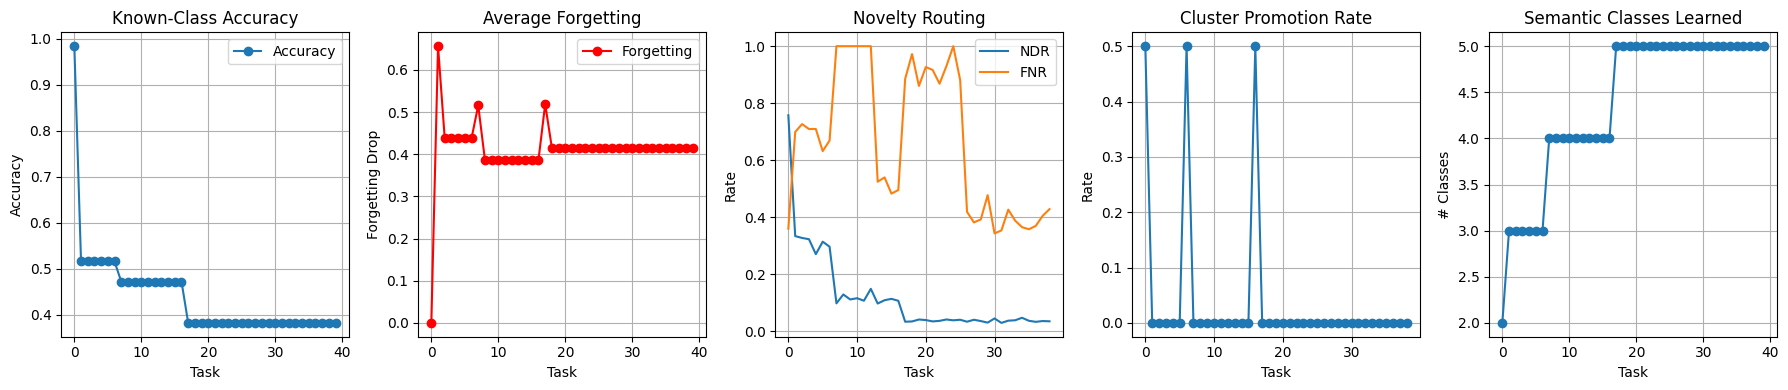

In [6]:
import os
# Must be set BEFORE importing any other libraries
os.environ['PYTHONHASHSEED'] = '42'
os.environ['CUBLAS_WORKSPACE_CONFIG'] = ':4096:8'

import random
import torch
import torch.nn as nn
import torch.nn.functional as F
import numpy as np
import matplotlib.pyplot as plt
from collections import defaultdict, Counter
from torch.utils.data import DataLoader, TensorDataset
from sklearn.manifold import TSNE
import torchvision.transforms as T
from torchvision.models import resnet18
import hdbscan
import copy

# LabelBench Imports
from LabelBench.skeleton.dataset_skeleton import datasets as DATASET_REGISTRY

# ============================================================
# REPRODUCIBILITY LOCK
# ============================================================
def set_seed(seed=42):
    """Forces deterministic behavior for absolute reproducibility."""
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed(seed)
        torch.cuda.manual_seed_all(seed)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False
    
    # Force PyTorch to use deterministic algorithms globally
    torch.use_deterministic_algorithms(True, warn_only=True)

set_seed(42)

# ============================================================
# DATALOADER GENERATOR FIX
# ============================================================
def seed_worker(worker_id):
    worker_seed = torch.initial_seed() % 2**32
    np.random.seed(worker_seed)
    random.seed(worker_seed)

g = torch.Generator()
g.manual_seed(42)

# ============================================================
# DIRECTORIES & CONFIGURATION (WAY 2 FOLDER)
# ============================================================
BASE_DIR = "way2_debug_raw_memory"

os.makedirs(BASE_DIR, exist_ok=True)
os.makedirs(f"{BASE_DIR}/tsne", exist_ok=True)
os.makedirs(f"{BASE_DIR}/tsne_supervised", exist_ok=True)
os.makedirs(f"{BASE_DIR}/tsne_finetune", exist_ok=True)
os.makedirs(f"{BASE_DIR}/hdbscan", exist_ok=True)
os.makedirs(f"{BASE_DIR}/drift", exist_ok=True)

NUM_TASKS = 40
DEVICE = "cuda" if torch.cuda.is_available() else "cpu"

P = 1                          
TOPK_NOVELTY = 400             
MAX_NOVELTY_BUFFER = 2000      

ALPHA = 0.35              
BETA = 0.01               
DELTA = 15                
MIN_CLUSTER_SIZE = 150    

CIFAR10_LABELS = {
    0: "airplane", 1: "automobile", 2: "bird", 3: "cat",
    4: "deer", 5: "dog", 6: "frog", 7: "horse",
    8: "ship", 9: "truck"
}

# ============================================================
# MODEL DEFINITION (COSINE CLASSIFIER + ARCFACE)
# ============================================================
class CNN(nn.Module):
    def __init__(self, num_classes):
        super().__init__()
        base = resnet18(weights='DEFAULT')
        
        base.conv1 = nn.Conv2d(3, 64, kernel_size=3, stride=1, padding=1, bias=False)
        base.maxpool = nn.Identity()
        
        self.encoder = nn.Sequential(*list(base.children())[:-1])
        self.embed = nn.Linear(512, 512)
        self.classifier = nn.Linear(512, num_classes, bias=False)
        self.scale = 20.0  

    def expand_head(self, new_classes):
        old_w = self.classifier.weight.data.clone()
        old_n = old_w.shape[0]
        new_classifier = nn.Linear(512, new_classes, bias=False).to(old_w.device)
        new_classifier.weight.data[:old_n] = old_w
        self.classifier = new_classifier

    def forward(self, x, labels=None):
        z = self.encoder(x)
        z = z.view(z.size(0), -1)
        z = self.embed(z)
            
        z = F.normalize(z, dim=1)
        W = F.normalize(self.classifier.weight, dim=1)
        cosine = torch.matmul(z, W.t())
    
        if labels is not None: 
            m = 0.2 
            theta = torch.acos(torch.clamp(cosine, -1+1e-7, 1-1e-7))
            target_logits = torch.cos(theta + m)
            one_hot = F.one_hot(labels, num_classes=W.size(0)).float()
            logits = cosine * (1 - one_hot) + target_logits * one_hot
        else:
            logits = cosine
    
        logits = logits * self.scale
        return logits, z

# ============================================================
# CENTROID DRIFT TRACKER
# ============================================================
class DebugCentroidTracker:
    def __init__(self):
        self.reference = {}
        self.history = defaultdict(list)

    def compute_centroids(self, model, memory):
        model.eval()
        centroids = {}
        with torch.no_grad():
            for cls, Xs in memory.items():
                if len(Xs) == 0: continue
                X = torch.stack([x for x, _ in Xs]).to(DEVICE)
                _, Z = model(X)
                mu = F.normalize(Z.mean(0), dim=0)
                centroids[cls] = mu.detach().cpu()
        return centroids

    def snapshot(self, model, memory):
        self.reference = self.compute_centroids(model, memory)

    def measure_drift(self, model, memory, epoch, tag=""):
        current = self.compute_centroids(model, memory)
        for cls in self.reference:
            if cls in current:
                drift = 1 - torch.dot(self.reference[cls], current[cls])
                self.history[(tag, cls)].append(drift.item())
                with open(f"{BASE_DIR}/drift/{tag}.txt", "a") as f:
                    f.write(f"Epoch {epoch} Class {cls}: {drift:.4f}\n")

    def plot_drift(self, tag):
        for (t, cls), values in self.history.items():
            if t == tag: plt.plot(values, label=f"class {cls}")
        plt.legend()
        plt.title(f"Centroid Drift {tag}")
        plt.xlabel("Checkpoint")
        plt.ylabel("1 - cosine similarity")
        plt.grid(True)
        plt.savefig(f"{BASE_DIR}/drift/{tag}_plot.png")
        plt.close()

# ============================================================
# MEMORY BUFFER (HERDING + BALANCED SAMPLING)
# ============================================================
class MemoryBuffer:
    def __init__(self, max_per_class=400):
        self.data = defaultdict(list)
        self.max_per_class = max_per_class
        self.aug = T.Compose([
            T.RandomCrop(32, padding=4),
            T.RandomHorizontalFlip()
        ])

    @torch.no_grad()
    def build_memory_herding(self, X_all, y_label, model):
        model.eval()
        logits_all, Z_all = [], []
        
        for i in range(0, len(X_all), 128):
            batch = X_all[i:i+128].to(DEVICE)
            logits, z = model(batch)
            logits_all.append(logits.cpu())
            Z_all.append(z.cpu())
            
        logits_all = torch.cat(logits_all)
        Z_all = torch.cat(Z_all)

        class_mean = F.normalize(Z_all.mean(0), dim=0)
        selected_idx = []
        features = Z_all.clone()

        for k in range(min(self.max_per_class, len(X_all))):
            if k > 0:
                S = Z_all[selected_idx].sum(0)
            else:
                S = torch.zeros_like(class_mean)
            
            target = (k + 1) * class_mean - S
            distances = torch.norm(features - target, dim=1)
            
            for idx in selected_idx:
                distances[idx] = float('inf')
            
            best = distances.argmin().item()
            selected_idx.append(best)

        self.data[int(y_label)] = []
        for idx in selected_idx:
            self.data[int(y_label)].append((X_all[idx].detach().cpu(), logits_all[idx].detach().cpu()))
    
    def get(self): return self.data

    def sample_balanced(self, batch_size, model):
        classes = list(self.data.keys())
        if not classes: return None, None, None
        
        samples_per_class = max(1, batch_size // len(classes))
        X_mem, Y_mem, L_mem = [], [], []
        current_dim = model.classifier.out_features
        
        for cls in classes:
            samples = self.data[cls]
            if len(samples) == 0: continue
            
            replace = len(samples) < samples_per_class
            idx = np.random.choice(len(samples), samples_per_class, replace=replace)
            
            for i in idx:
                x, logit = samples[i]
                if logit.shape[0] < current_dim:
                    padded = torch.zeros(current_dim)
                    padded[:logit.shape[0]] = logit
                    logit = padded
                X_mem.append(x)
                Y_mem.append(cls)
                L_mem.append(logit)
                
        if not X_mem: return None, None, None
        
        X_tensor = torch.stack(X_mem)
        X_tensor = self.aug(X_tensor) 
        return X_tensor, torch.tensor(Y_mem), torch.stack(L_mem)

# ============================================================
# HYPERSPHERE NOVELTY DETECTOR
# ============================================================
class HypersphereNovelty:
    def __init__(self, q=0.90):
        self.q = q
        self.mu, self.r = {}, {}

    def update(self, memory, model):
        self.mu, self.r = {}, {}
        for k, X_tuples in memory.items():
            if len(X_tuples) == 0: continue
            X = torch.stack([x for x, _ in X_tuples]).to(DEVICE)
            with torch.no_grad(): 
                _, Z = model(X)
            mu = F.normalize(Z.mean(0), dim=0)
            d = 1 - torch.matmul(Z, mu)
            self.mu[k] = mu
            self.r[k] = torch.quantile(d, self.q)

    def score(self, z):
        if not self.mu: return torch.tensor(0.0)
        return min([(1 - torch.dot(z, self.mu[k].to(z.device))) - self.r[k].to(z.device) for k in self.mu])

# ============================================================
# TRAINING HELPERS (SUPERVISED & CL FINETUNING)
# ============================================================
def train_supervised(model, loader, test_loader, task_id):
    opt = torch.optim.Adam(model.parameters(), lr=1e-4, weight_decay=1e-4)
    model.train()
    
    aug = T.Compose([
        T.RandomCrop(32, padding=4), 
        T.RandomHorizontalFlip()
    ])
    
    for epoch in range(30):
        if epoch % 5 == 0:
            visualize_epoch_tsne(model, test_loader, task_id, epoch, known_semantics=set(semantic_to_internal.keys()), phase="supervised")
        for x, y in loader:
            x, y = x.to(DEVICE), y.argmax(1).to(DEVICE)
            x = aug(x)
            loss = F.cross_entropy(model(x, y)[0], y)
            opt.zero_grad()
            loss.backward()
            opt.step()

def finetune(model, memory, X_new, new_label, task_id, test_loader): 
    old_model = copy.deepcopy(model).eval()
    for p in old_model.parameters(): p.requires_grad = False 

    debug_tracker = DebugCentroidTracker()
    debug_tracker.snapshot(model, memory.data)
    
    model.train()
    aug = T.Compose([T.RandomCrop(32, padding=4), T.RandomHorizontalFlip()])
    
    Y_new = torch.full((len(X_new),), new_label, dtype=torch.long)
    # Applied worker_init_fn and generator
    loader = DataLoader(
        TensorDataset(X_new, Y_new), 
        batch_size=32, 
        shuffle=True, 
        worker_init_fn=seed_worker, 
        generator=g
    )

    for p in model.parameters(): p.requires_grad = True
        
    opt = torch.optim.Adam(model.parameters(), lr=5e-5, weight_decay=1e-4)

    visualize_epoch_tsne(model, test_loader, task_id, epoch="before", known_semantics=set(semantic_to_internal.keys()), phase="finetune")

    for epoch in range(15):
        for xb, yb in loader:
            xb = aug(xb) 
            X_mem, Y_mem, L_mem = memory.sample_balanced(32, model)

            if X_mem is not None:
                xb = torch.cat([xb, X_mem], dim=0)
                yb = torch.cat([yb, Y_mem], dim=0)

            xb, yb = xb.to(DEVICE), yb.to(DEVICE)
            
            logits_margin, Z = model(xb, yb)
            loss_ce = F.cross_entropy(logits_margin, yb)
            
            if X_mem is not None:
                pure_logits, _ = model(xb) 
                logits_mem = pure_logits[-len(X_mem):]
                loss_der = F.mse_loss(logits_mem, L_mem.to(DEVICE))
            else:
                loss_der = torch.tensor(0.0, device=DEVICE)

            with torch.no_grad(): 
                logits_old, Z_old = old_model(xb)

            loss_feat = (1 - F.cosine_similarity(Z, Z_old)).mean()
            loss = loss_ce + 0.5 * loss_der + 1.0 * loss_feat
            
            opt.zero_grad()
            loss.backward()
            opt.step()

        if epoch % 5 == 0:
            visualize_epoch_tsne(model, test_loader, task_id, epoch, known_semantics=set(semantic_to_internal.keys()), phase="finetune")
            debug_tracker.measure_drift(model, memory.data, epoch, tag=f"FT_Task{task_id}")

    model.eval()
    return debug_tracker

# ============================================================
# TSNE VISUALIZATIONS
# ============================================================
def visualize_tsne(model, loader, task_id, known_semantics, tag=""):
    model.eval()
    Z_all, Y_all = [], []
    with torch.no_grad():
        for x, y in loader:
            _, z = model(x.to(DEVICE))
            y = y.argmax(1)
            mask = torch.tensor([int(label.item()) in known_semantics for label in y])
            if mask.sum() > 0: 
                Z_all.append(z[mask].cpu())
                Y_all.append(y[mask].cpu())
    if not Z_all: return
    
    Z_all, Y_all = torch.cat(Z_all).numpy(), torch.cat(Y_all).numpy()
    n_samples = len(Z_all)
    
    if n_samples < 2: return 
    
    if n_samples > 3000: 
        idx = np.random.choice(n_samples, 3000, replace=False)
        Z_all, Y_all = Z_all[idx], Y_all[idx]
        n_samples = 3000
    
    perp = min(30, n_samples - 1)
    tsne = TSNE(n_components=2, perplexity=perp, metric="cosine", random_state=42, init="pca")
    Z_2d = tsne.fit_transform(Z_all)
    
    plt.figure(figsize=(7,6))
    for label in sorted(np.unique(Y_all)):
        plt.scatter(Z_2d[Y_all == label, 0], Z_2d[Y_all == label, 1], s=12, alpha=0.6, label=CIFAR10_LABELS[int(label)])
    plt.title(f"Task {task_id} ({tag})")
    plt.legend(fontsize=8)
    plt.grid(True)
    plt.tight_layout()
    filename = f"task_{task_id}_{tag}" if tag else f"task_{task_id}"
    plt.savefig(f"{BASE_DIR}/tsne/{filename}.png")
    plt.close()

def visualize_epoch_tsne(model, test_loader, task_id, epoch, known_semantics, phase="supervised"):
    model.eval()
    Z_all, Y_all = [], []
    with torch.no_grad():
        for x, y in test_loader:
            _, z = model(x.to(DEVICE))
            y = y.argmax(1)
            mask = torch.tensor([int(label.item()) in known_semantics for label in y])
            if mask.sum() > 0: 
                Z_all.append(z[mask].cpu())
                Y_all.append(y[mask].cpu())
    if not Z_all: return
    
    Z_all, Y_all = torch.cat(Z_all).numpy(), torch.cat(Y_all).numpy()
    n_samples = len(Z_all)
    if n_samples < 2: return
    
    if n_samples > 3000: 
        idx = np.random.choice(n_samples, 3000, replace=False)
        Z_all, Y_all = Z_all[idx], Y_all[idx]
        n_samples = 3000
        
    perp = min(30, n_samples - 1)
    tsne = TSNE(n_components=2, perplexity=perp, metric="cosine", random_state=42, init="pca")
    Z_2d = tsne.fit_transform(Z_all)
    
    plt.figure(figsize=(7,6))
    for label in sorted(np.unique(Y_all)):
        plt.scatter(Z_2d[Y_all == label, 0], Z_2d[Y_all == label, 1], s=12, alpha=0.6, label=CIFAR10_LABELS[int(label)])
    plt.title(f"{phase} | Task {task_id} | Epoch {epoch}")
    plt.legend(fontsize=8)
    plt.grid(True)
    plt.tight_layout()
    save_path = f"{BASE_DIR}/tsne_{phase}/task{task_id}_epoch{epoch}.png"
    plt.savefig(save_path)
    plt.close()

def visualize_clusters(Z, labels, task_id):
    n_samples = len(Z)
    if n_samples < 2: 
        print(f"⚠️  [DEBUG] Only {n_samples} points in buffer. Skipping cluster visualization.")
        return
        
    perp = min(30, n_samples - 1)
    tsne = TSNE(n_components=2, perplexity=perp, random_state=42)
    Z_2d = tsne.fit_transform(Z)

    plt.figure(figsize=(6,5))
    for cid in set(labels):
        mask = labels == cid
        if cid == -1:
            plt.scatter(Z_2d[mask,0], Z_2d[mask,1], s=10, alpha=0.3, label="Noise")
        else:
            plt.scatter(Z_2d[mask,0], Z_2d[mask,1], s=15, alpha=0.7, label=f"Cluster {cid}")

    plt.legend()
    plt.title(f"Cluster Structure Task {task_id}")
    plt.grid(True)
    plt.savefig(f"{BASE_DIR}/hdbscan/task_{task_id}.png")
    plt.close()

# ============================================================
# EVALUATION HELPER FOR ACCURACY & FORGETTING
# ============================================================
def evaluate_class_metrics(model, test_ds, semantic_to_internal, t, class_accuracies):
    correct_per_class = defaultdict(int)
    total_per_class = defaultdict(int)
    
    model.eval()
    with torch.no_grad():
        for x_test, y_test in DataLoader(test_ds, batch_size=128):
            x_test = x_test.to(DEVICE)
            y_test = y_test.argmax(1).to(DEVICE)
            logits, _ = model(x_test)
            preds = logits.argmax(1)
            
            for i in range(len(y_test)):
                sem = int(y_test[i])
                if sem in semantic_to_internal:
                    internal_gt = semantic_to_internal[sem]
                    total_per_class[sem] += 1
                    if preds[i].item() == internal_gt:
                        correct_per_class[sem] += 1

    current_class_accs = {}
    total_known_correct = 0
    total_known_eval = 0
    
    for sem in semantic_to_internal.keys():
        total_known_correct += correct_per_class[sem]
        total_known_eval += total_per_class[sem]
        current_class_accs[sem] = correct_per_class[sem] / max(total_per_class[sem], 1)
        
    class_accuracies[t] = current_class_accs
    
    kca = total_known_correct / max(total_known_eval, 1)
    
    if t > 0:
        forgetting_list = []
        for sem in current_class_accs.keys():
            past_accs = [class_accuracies[k].get(sem, None) for k in range(t) if k in class_accuracies]
            past_accs = [a for a in past_accs if a is not None]
            if past_accs:
                max_past = max(past_accs)
                forgetting = max_past - current_class_accs[sem]
                forgetting_list.append(forgetting)
        avg_forg = np.mean(forgetting_list) if forgetting_list else 0.0
    else:
        avg_forg = 0.0
        
    return kca, avg_forg, current_class_accs

# ============================================================
# METRIC STORAGE & INITIALIZATION
# ============================================================

task_kca, task_ndr, task_fnr, task_cpr = [], [], [], []
average_forgetting = [] 
class_accuracies = {}   
learned_classes_over_time = []
promoted_classes_log = []

TASKS = [f"splitcifar10_{i}" for i in range(NUM_TASKS)]

model = CNN(num_classes=2).to(DEVICE)
memory = MemoryBuffer(max_per_class=200)
detector = HypersphereNovelty()

novelty_buffer = []

semantic_to_internal = {0: 0, 1: 1}
internal_to_semantic = {0: 0, 1: 1}
known_classes = 2

_, dataset_fn = DATASET_REGISTRY[TASKS[0]]
_, test_ds, *_ = dataset_fn("./data")
print("\n[TSNE] Before Training")
visualize_tsne(model, DataLoader(test_ds, batch_size=128, shuffle=False), -1, known_semantics=set(semantic_to_internal.keys()))

# ============================================================
# MAIN OPEN-WORLD CONTINUAL LEARNING LOOP
# ============================================================

for t, task in enumerate(TASKS):

    print(f"\n{'='*20} 🚀 TASK {t} {'='*20}")

    _, dataset_fn = DATASET_REGISTRY[task]
    train_ds, test_ds, *_ = dataset_fn("./data")
    
    # Applied worker_init_fn and generator
    loader = DataLoader(
        train_ds, 
        batch_size=64, 
        shuffle=True, 
        worker_init_fn=seed_worker, 
        generator=g
    ) 

    all_semantics = []
    for _, y in loader: all_semantics.extend(y.argmax(1).tolist())
    unique_semantics = list(set(all_semantics))
    class_names = [CIFAR10_LABELS[sem] for sem in unique_semantics]
    print(f"📦 [STREAM] Task {t} stream contains class(es): {class_names} (Label IDs: {unique_semantics})")
    print(f"📊 [STREAM] Total images in this chunk: {len(train_ds)}")

    if t == 0:
        print("🎓 [INIT] Running supervised baseline on Task 0...")
        train_supervised(model, loader, DataLoader(test_ds, batch_size=128, shuffle=False), t)

        for cls in [0, 1]:
            Xc = torch.cat([x[y.argmax(1) == cls] for x, y in loader])
            memory.build_memory_herding(Xc, cls, model)

        detector.update(memory.get(), model)
        visualize_tsne(model, DataLoader(test_ds, batch_size=128, shuffle=False), t, known_semantics=set(semantic_to_internal.keys()))
        
        learned_classes_over_time.append({CIFAR10_LABELS[0], CIFAR10_LABELS[1]})
        print(f"✅ [INIT COMPLETE] Known classes: {learned_classes_over_time[-1]}")
        
        acc, avg_forg, current_class_accs = evaluate_class_metrics(model, test_ds, semantic_to_internal, t, class_accuracies)
        task_kca.append(acc)
        average_forgetting.append(avg_forg)
        
        print(f"📈 [METRIC] Known-Class Acc: {acc:.3f} | Avg Forgetting: {avg_forg:.3f}")
        for sem, c_acc in current_class_accs.items():
            print(f"   ➔ Class '{CIFAR10_LABELS[sem]}' Acc: {c_acc:.3f}")

        promoted_classes_log.append({
            "task": 0,
            "semantic": f"{CIFAR10_LABELS[0]} & {CIFAR10_LABELS[1]}",
            "purity": 1.0,
            "stats": "Base Supervised Initialization",
            "acc": acc
        })
        
        continue

    model.eval()
    novelty_candidates = []
    novel, false_novel, total = 0, 0, 0

    with torch.no_grad():
        for x, y in loader:
            _, z = model(x.to(DEVICE))
            y = y.argmax(1)

            scores = [detector.score(z[i]).item() for i in range(len(z))]
            
            # --- OPEN WORLD FIX 1: Dynamic Absolute Thresholding ---
            thr = 0.0

            for i in range(len(z)):
                total += 1
                if scores[i] > thr:
                    novelty_candidates.append((scores[i], x[i].cpu(), y[i].item()))
                    novel += 1
                    if y[i].item() in semantic_to_internal:
                        false_novel += 1

    task_ndr.append(novel / max(total, 1))
    task_fnr.append(false_novel / max(novel, 1))

    print(f"🔍 [NOVELTY] Flagged Novel: {novel}/{total} | False Novelty (Knowns flagged): {false_novel}")

    novelty_candidates.sort(reverse=True, key=lambda x: x[0])
    novelty_buffer.extend([(img, y) for _, img, y in novelty_candidates[:TOPK_NOVELTY]])
    novelty_buffer = novelty_buffer[-MAX_NOVELTY_BUFFER:]

    if t % P == 0:
        print(f"\n🧠 [CLUSTERING] Running HDBSCAN on novelty buffer (Size: {len(novelty_buffer)})...")
        
        if len(novelty_buffer) < 2:
            print("  ⚠️  [DEBUG] Not enough samples to cluster. Skipping...")
            task_cpr.append(0.0)
            continue
        
        Z = []
        with torch.no_grad():
            for img, _ in novelty_buffer:
                _, z = model(img.unsqueeze(0).to(DEVICE))
                Z.append(z.squeeze().cpu().numpy())

        Z = np.stack(Z)
        
        labels = hdbscan.HDBSCAN(metric='euclidean', min_cluster_size=40).fit_predict(Z)
        
        visualize_clusters(Z, labels, t)
        
        new_buffer = []
        found, promoted = 0, 0

        for cid in sorted(set(labels)):
            idxs = np.where(labels == cid)[0]

            if cid == -1:
                print(f"  🗑️  [CLUSTER -1] NOISE: Found {len(idxs)} noise samples.")
                for i in idxs: new_buffer.append(novelty_buffer[i])
                continue

            found += 1
            Xc = torch.stack([novelty_buffer[i][0] for i in idxs])

            with torch.no_grad():
                _, Zc = model(Xc.to(DEVICE))

            mu = F.normalize(Zc.mean(0), dim=0)
            n = len(idxs)
            S_intra = torch.mean(1 - torch.matmul(Zc, mu))

            if len(detector.mu) > 0:
                S_known = min([1 - torch.dot(mu, detector.mu[k].to(mu.device)) for k in detector.mu])
            else:
                S_known = torch.tensor(1.0)

            density = n / (S_intra.item() + 1e-6)
            margin = S_known - S_intra
            
            labels_true = [novelty_buffer[i][1] for i in idxs]
            sem_label, cnt = Counter(labels_true).most_common(1)[0]
            purity = cnt / len(labels_true)

            if sem_label in semantic_to_internal:
                print(f"\n  ⚠️  [CLUSTER {cid}] SKIPPED: Dominant class '{CIFAR10_LABELS[sem_label]}' is already known.")
                continue

            cond_intra = S_intra.item() <= ALPHA
            cond_density = density >= DELTA
            cond_known = S_known.item() >= BETA
            cond_margin = margin.item() > -0.10
            cond_size = n >= MIN_CLUSTER_SIZE

            print(f"\n  📊 [CLUSTER {cid} EVALUATION] Dominant: '{CIFAR10_LABELS[sem_label]}' (Purity: {purity:.2f})")
            print(f"     ➔ Size:    {n:3d}   (Req: >= {MIN_CLUSTER_SIZE:2d})   {'✅' if cond_size else '❌'}")
            print(f"     ➔ S_intra: {S_intra.item():.3f} (Req: <= {ALPHA:.2f}) {'✅' if cond_intra else '❌'}")
            print(f"     ➔ S_known: {S_known.item():.3f} (Req: >= {BETA:.2f}) {'✅' if cond_known else '❌'}")
            print(f"     ➔ Density: {density:.1f} (Req: >= {DELTA})   {'✅' if cond_density else '❌'}")
            print(f"     ➔ Margin:  {margin.item():.3f} (Req: > -0.10) {'✅' if cond_margin else '❌'}")

            if cond_intra and cond_density and cond_known and cond_margin and cond_size:
                promoted += 1
                new_label = known_classes

                semantic_to_internal[sem_label] = new_label
                internal_to_semantic[new_label] = sem_label
                known_classes += 1

                model.expand_head(known_classes)
                model.to(DEVICE)

                print(f"     🎉 [PROMOTION SUCCESS] -> Preparing to Finetune '{CIFAR10_LABELS[sem_label]}'...")
                debug_tracker = finetune(model, memory, Xc, new_label, t, DataLoader(test_ds, batch_size=128, shuffle=False))
                debug_tracker.plot_drift(f"FT_Task{t}")
                
                memory.build_memory_herding(Xc, new_label, model)
                detector.update(memory.get(), model)

                promoted_classes_log.append({
                    "task": t,
                    "semantic": CIFAR10_LABELS[sem_label],
                    "purity": purity,
                    "stats": f"size={n}, S_intra={S_intra.item():.3f}, S_known={S_known.item():.3f}, dens={density:.1f}, margin={margin.item():.3f}",
                    "acc": None
                })

                print(f"     ✨ [LEARNED] -> Network successfully adapted to '{CIFAR10_LABELS[sem_label]}'")
            else:
                print(f"     🛑 [PROMOTION FAILED] -> Conditions not met. Retaining samples in buffer.")
                for i in idxs: new_buffer.append(novelty_buffer[i])

        novelty_buffer = new_buffer
        task_cpr.append(promoted / max(found, 1))
    else:
        task_cpr.append(0.0)

    # --- OPEN WORLD FIX 2: Continuous Buffer Operation ---

    learned_classes_over_time.append(
        set(learned_classes_over_time[-1]) if len(learned_classes_over_time) > 0 else set()
    )

    for p in promoted_classes_log:
        if p["task"] == t and p["semantic"] not in learned_classes_over_time[-1]:
            learned_classes_over_time[-1].add(p["semantic"])

    acc, avg_forg, current_class_accs = evaluate_class_metrics(model, test_ds, semantic_to_internal, t, class_accuracies)
    task_kca.append(acc)
    average_forgetting.append(avg_forg)
    
    print(f"📈 [METRIC] Known-Class Acc: {acc:.3f} | Avg Forgetting: {avg_forg:.3f}")
    for sem, c_acc in current_class_accs.items():
        print(f"   ➔ Class '{CIFAR10_LABELS[sem]}' Acc: {c_acc:.3f}")

    visualize_tsne(model, DataLoader(test_ds, batch_size=128, shuffle=False), t, known_semantics=set(semantic_to_internal.keys()))

    for p in promoted_classes_log:
        if p["task"] == t and p.get("acc") is None:
            p["acc"] = acc

# ============================================================
# FINAL SUMMARY & VISUALIZATION
# ============================================================

print("\n" + "="*40)
print("🏆 FINAL DISCOVERY SUMMARY")
print("="*40)

if len(learned_classes_over_time) > 0:
    print(f"Initial classes: {learned_classes_over_time[0]}")
    print(f"Final learned classes: {learned_classes_over_time[-1]}")

print("\nPromoted classes timeline:")
for p in promoted_classes_log:
    if p["task"] == 0:
        print(f"Task {p['task']:02d} → {p['semantic']:<22} (Init   | Acc: {p['acc']:.3f} | {p['stats']})")
    else:
        print(f"Task {p['task']:02d} → {p['semantic']:<22} (purity={p['purity']:.2f} | Acc: {p['acc']:.3f} | stats: {p['stats']})")

print("\n" + "="*40)
print("📊 TASK-BY-TASK ACCURACY & FORGETTING TIMELINE")
print("="*40)
for task_idx in range(NUM_TASKS):
    if task_idx in class_accuracies:
        acc_str = ", ".join([f"{CIFAR10_LABELS[sem]}: {class_accuracies[task_idx][sem]:.3f}" for sem in class_accuracies[task_idx]])
        print(f"Task {task_idx:02d} | KCA: {task_kca[task_idx]:.3f} | Avg Forgetting: {average_forgetting[task_idx]:.3f} | Class Accs: [{acc_str}]")

plt.figure(figsize=(18,4))

plt.subplot(1,5,1)
plt.plot(task_kca, marker='o', label="Accuracy")
plt.title("Known-Class Accuracy")
plt.xlabel("Task")
plt.ylabel("Accuracy")
plt.grid(True)
plt.legend()

plt.subplot(1,5,2)
plt.plot(average_forgetting, marker='o', color='red', label="Forgetting")
plt.title("Average Forgetting")
plt.xlabel("Task")
plt.ylabel("Forgetting Drop")
plt.grid(True)
plt.legend()

plt.subplot(1,5,3)
plt.plot(task_ndr, label="NDR")
plt.plot(task_fnr, label="FNR")
plt.title("Novelty Routing")
plt.xlabel("Task")
plt.ylabel("Rate")
plt.legend()
plt.grid(True)

plt.subplot(1,5,4)
plt.plot(task_cpr, marker='o')
plt.title("Cluster Promotion Rate")
plt.xlabel("Task")
plt.ylabel("Rate")
plt.grid(True)

plt.subplot(1,5,5)
plt.plot([len(set_) for set_ in learned_classes_over_time], marker='o')
plt.title("Semantic Classes Learned")
plt.xlabel("Task")
plt.ylabel("# Classes")
plt.grid(True)

plt.tight_layout()
plt.show()